In [ ]:
!pip install gdown -q

In [ ]:
!pip install lazypredict -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 774.7/774.7 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 8.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.feature_selection import mutual_info_classif
import gdown
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [ ]:
url = 'https://drive.google.com/file/d/1uCFvcPHO-bchVYWDDtfc7R1Lzr1rSGCI/view?usp=sharing'
url = 'https://drive.google.com/uc?id=' + url.split('/')[-2]

output = 'df_clean_modeling.parquet'
gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1uCFvcPHO-bchVYWDDtfc7R1Lzr1rSGCI
To: /content/df_clean_modeling.parquet
100%|██████████| 54.3M/54.3M [00:00<00:00, 76.9MB/s]


'df_clean_modeling.parquet'

In [ ]:
cleaned_database = pd.read_parquet("df_clean_modeling.parquet")

In [ ]:
cleaned_database.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6965266 entries, 0 to 6965265
Data columns (total 14 columns):
 #   Column              Dtype  
---  ------              -----  
 0   mes                 int64  
 1   dia_mes             int64  
 2   dia_semana          int64  
 3   fin_de_semana       int64  
 4   hora_salida         int64  
 5   minuto_salida       int64  
 6   distancia_millas    float64
 7   tiempo_programado   float64
 8   aerolinea           object 
 9   aeropuerto_origen   object 
 10  aeropuerto_destino  object 
 11  estado_origen       object 
 12  estado_destino      object 
 13  vuelo_retrasado     int64  
dtypes: float64(2), int64(7), object(5)
memory usage: 744.0+ MB


In [ ]:
cleaned_database.describe(include=['object'])

,aerolinea,aeropuerto_origen,aeropuerto_destino,estado_origen,estado_destino
count,6965266,6965266,6965266,6965266,6965266
unique,15,348,348,52,52
top,WN,ATL,ATL,Texas,Texas
freq,1404597,337662,337703,738049,737002


In [ ]:
cleaned_database.describe(include=['float64', 'int64'])

,mes,dia_mes,dia_semana,fin_de_semana,hora_salida,minuto_salida,distancia_millas,tiempo_programado,vuelo_retrasado
count,6.965266e+06,6.965266e+06,6.965266e+06,6.965266e+06,6.965266e+06,6.965266e+06,6.965266e+06,6.965266e+06,6.965266e+06
mean,6.597649e+00,1.579056e+01,3.981578e+00,2.767482e-01,1.299242e+01,2.690934e+01,8.336728e+02,1.467058e+02,1.994017e-01
std,3.397294e+00,8.794847e+00,2.012222e+00,4.473910e-01,4.897564e+00,1.820890e+01,5.963388e+02,7.239773e+01,3.995506e-01
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.100000e+01,6.000000e+00,0.000000e+00
25%,4.000000e+00,8.000000e+00,2.000000e+00,0.000000e+00,9.000000e+00,1.000000e+01,3.990000e+02,9.300000e+01,0.000000e+00
50%,7.000000e+00,1.600000e+01,4.000000e+00,0.000000e+00,1.300000e+01,2.700000e+01,6.800000e+02,1.300000e+02,0.000000e+00
75%,1.000000e+01,2.300000e+01,6.000000e+00,1.000000e+00,1.700000e+01,4.300000e+01,1.069000e+03,1.770000e+02,0.000000e+00
max,1.200000e+01,3.100000e+01,7.000000e+00,1.000000e+00,2.300000e+01,5.900000e+01,5.095000e+03,8.590000e+02,1.000000e+00


In [ ]:
cleaned_database.head(110)

,mes,dia_mes,dia_semana,fin_de_semana,hora_salida,minuto_salida,distancia_millas,tiempo_programado,aerolinea,aeropuerto_origen,aeropuerto_destino,estado_origen,estado_destino,vuelo_retrasado
0,1,1,1,0,12,52,509.0,136.0,9E,JFK,DTW,New York,Michigan,0
1,1,1,1,0,10,15,622.0,130.0,9E,MSP,CLE,Minnesota,Ohio,0
2,1,1,1,0,14,15,288.0,106.0,9E,JFK,RIC,New York,Virginia,0
3,1,1,1,0,16,50,288.0,111.0,9E,RIC,JFK,Virginia,New York,0
4,1,1,1,0,10,15,237.0,79.0,9E,DTW,MKE,Michigan,Wisconsin,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,1,1,1,0,14,23,620.0,135.0,9E,MDT,ATL,Pennsylvania,Georgia,0
106,1,1,1,0,19,40,209.0,105.0,9E,JFK,SYR,New York,New York,0
107,1,1,1,0,16,45,629.0,137.0,9E,DTW,MCI,Michigan,Missouri,1
108,1,1,1,0,10,40,563.0,129.0,9E,LGA,MYR,New York,South Carolina,1


DE AQUI SEPARE

In [ ]:

df_sorted = cleaned_database.sort_values(by=['mes', 'dia_mes', 'hora_salida', 'minuto_salida'])


In [ ]:
df_sorted.head()

,mes,dia_mes,dia_semana,fin_de_semana,hora_salida,minuto_salida,distancia_millas,tiempo_programado,aerolinea,aeropuerto_origen,aeropuerto_destino,estado_origen,estado_destino,vuelo_retrasado
11452,1,1,1,0,0,8,1846.0,262.0,UA,SFO,ORD,California,Illinois,0
6218,1,1,1,0,0,9,2171.0,291.0,F9,ONT,MCO,California,Florida,0
6651,1,1,1,0,0,9,1506.0,205.0,F9,DEN,TPA,Colorado,Florida,0
4239,1,1,1,0,0,20,1589.0,213.0,DL,SFO,MSP,California,Minnesota,0
2996,1,1,1,0,0,25,1448.0,215.0,AS,ANC,SEA,Alaska,Washington,0


In [ ]:
# 2. DEFINICIÓN DE TAMAÑOS FIJOS
# No usamos porcentajes. 200k muestras son suficientes para validar la robustez del modelo.
TEST_SIZE = 200000
VAL_SIZE = 200000

In [ ]:
# Calculamos los índices de corte
total_rows = len(df_sorted)
test_start_index = total_rows - TEST_SIZE
val_start_index = test_start_index - VAL_SIZE

In [ ]:
# 3. REALIZAR EL SPLIT TEMPORAL (Slicing)
# Train: Desde el inicio hasta el comienzo de validación
train_df = df_sorted.iloc[:val_start_index].copy()

In [ ]:
# Validation: El bloque intermedio
val_df = df_sorted.iloc[val_start_index:test_start_index].copy()

# Test: El bloque final (el "futuro" más lejano)
test_df = df_sorted.iloc[test_start_index:].copy()

In [ ]:
# 4. SEPARACIÓN X (Features) e y (Target)
target = 'vuelo_retrasado'
cols_to_drop = [target]

X_train = train_df.drop(columns=cols_to_drop)
y_train = train_df[target]

X_val = val_df.drop(columns=cols_to_drop)
y_val = val_df[target]

X_test = test_df.drop(columns=cols_to_drop)
y_test = test_df[target]

In [ ]:
# --- VERIFICACIÓN DE SEGURIDAD ---
print(f"Dimensiones del Dataset:")
print(f"  Train: {X_train.shape} ({len(X_train)/total_rows:.1%} del total)")
print(f"  Val:   {X_val.shape}")
print(f"  Test:  {X_test.shape}")


Dimensiones del Dataset:
  Train: (6565266, 13) (94.3% del total)
  Val:   (200000, 13)
  Test:  (200000, 13)


In [ ]:
# Verificamos que no haya superposición temporal (Data Leakage Check)
print("Verificación Temporal:")
print(f"  Train termina en mes: {X_train['mes'].max()} (aprox)")
print(f"  Val empieza en mes:   {X_val['mes'].min()} (aprox)")
print(f"  Test empieza en mes:  {X_test['mes'].min()} (aprox)")

Verificación Temporal:
  Train termina en mes: 12 (aprox)
  Val empieza en mes:   12 (aprox)
  Test empieza en mes:  12 (aprox)


In [ ]:
print(f"  Train empieza en mes: {X_train['mes'].min()} (aprox)")

  Train empieza en mes: 1 (aprox)


In [ ]:
print(f"Train termina el día: {train_df['dia_mes'].iloc[-1]} del mes {train_df['mes'].iloc[-1]}")
print(f"Val abarca del día: {val_df['dia_mes'].min()} al {val_df['dia_mes'].max()}")
print(f"Test empieza el día: {test_df['dia_mes'].iloc}")

Train termina el día: 10 del mes 12
Val abarca del día: 10 al 21
Test empieza el día: <pandas.core.indexing._iLocIndexer object at 0x7fa8e3388c30>


In [ ]:

# Copias de seguridad para no afectar los dataframes originales
X_train_proc = X_train.copy()
X_val_proc = X_val.copy()
X_test_proc = X_test.copy()

A. PREPARACIÓN DE COLUMNAS CICLICAS

In [ ]:
def encode_cycle_safe(data, col, max_val):
    # Usamos max_val fijo (teórico) en vez de data[col].max()
    data[col + '_sin'] = np.sin(2 * np.pi * data[col] / max_val)
    data[col + '_cos'] = np.cos(2 * np.pi * data[col] / max_val)
    return data


In [ ]:
# 1. Ciclos Diarios y Semanales
X_train_proc = encode_cycle_safe(X_train_proc, 'mes', 12)          # Ciclo anual
X_train_proc = encode_cycle_safe(X_train_proc, 'dia_semana', 7)    # Ciclo semanal

# 2. Ciclos Horarios (Tus nuevas variables)
X_train_proc = encode_cycle_safe(X_train_proc, 'dia_mes', 31)      # Ciclo mensual
X_train_proc = encode_cycle_safe(X_train_proc, 'hora_salida', 24)  # Ciclo diario (horas)
X_train_proc = encode_cycle_safe(X_train_proc, 'minuto_salida', 60)# Ciclo horario (m

# 1. Ciclos Diarios y Semanales
X_val_proc = encode_cycle_safe(X_val_proc, 'mes', 12)          # Ciclo anual
X_val_proc = encode_cycle_safe(X_val_proc, 'dia_semana', 7)    # Ciclo semanal

# 2. Ciclos Horarios (Tus nuevas variables)
X_val_proc = encode_cycle_safe(X_val_proc, 'dia_mes', 31)      # Ciclo mensual
X_val_proc = encode_cycle_safe(X_val_proc, 'hora_salida', 24)  # Ciclo diario (horas)
X_val_proc = encode_cycle_safe(X_val_proc, 'minuto_salida', 60)# Ciclo horario (m



# 1. Ciclos Diarios y Semanales
X_test_proc = encode_cycle_safe(X_test_proc, 'mes', 12)          # Ciclo anual
X_test_proc = encode_cycle_safe(X_test_proc, 'dia_semana', 7)    # Ciclo semanal

# 2. Ciclos Horarios (Tus nuevas variables)
X_test_proc = encode_cycle_safe(X_test_proc, 'dia_mes', 31)      # Ciclo mensual
X_test_proc = encode_cycle_safe(X_test_proc, 'hora_salida', 24)  # Ciclo diario (horas)
X_test_proc = encode_cycle_safe(X_test_proc, 'minuto_salida', 60)# Ciclo horario (m





In [ ]:
X_train_proc.head()

,mes,dia_mes,dia_semana,fin_de_semana,hora_salida,minuto_salida,distancia_millas,tiempo_programado,aerolinea,aeropuerto_origen,...,mes_sin,mes_cos,dia_semana_sin,dia_semana_cos,dia_mes_sin,dia_mes_cos,hora_salida_sin,hora_salida_cos,minuto_salida_sin,minuto_salida_cos
11452,1,1,1,0,0,8,1846.0,262.0,UA,SFO,...,0.5,0.866025,0.781831,0.62349,0.201299,0.97953,0.0,1.0,0.743145,0.669131
6218,1,1,1,0,0,9,2171.0,291.0,F9,ONT,...,0.5,0.866025,0.781831,0.62349,0.201299,0.97953,0.0,1.0,0.809017,0.587785
6651,1,1,1,0,0,9,1506.0,205.0,F9,DEN,...,0.5,0.866025,0.781831,0.62349,0.201299,0.97953,0.0,1.0,0.809017,0.587785
4239,1,1,1,0,0,20,1589.0,213.0,DL,SFO,...,0.5,0.866025,0.781831,0.62349,0.201299,0.97953,0.0,1.0,0.866025,-0.500000
2996,1,1,1,0,0,25,1448.0,215.0,AS,ANC,...,0.5,0.866025,0.781831,0.62349,0.201299,0.97953,0.0,1.0,0.500000,-0.866025


In [ ]:
# 3. Eliminar las columnas originales para evitar multicolinealidad y ruido
# Las redes neuronales aprenden mejor si no tienen información redundante
columnas_a_borrar = ['mes', 'dia_semana', 'dia_mes', 'hora_salida', 'minuto_salida']
X_train_proc.drop(columns=columnas_a_borrar, inplace=True)
X_val_proc.drop(columns=columnas_a_borrar, inplace=True)
X_test_proc.drop(columns=columnas_a_borrar, inplace=True)

B. INGENIERÍA DE CATEGORÍAS (BACK-OFF / TOP-N)

In [ ]:
categorical_columns = ['aerolinea', 'aeropuerto_origen', 'estado_origen', 'aeropuerto_destino', 'estado_destino']

print("Valores únicos de columnas categóricas")
for column in categorical_columns:
  print(f"{column}: {X_train_proc[column].nunique()}")

Valores únicos de columnas categóricas
aerolinea: 15
aeropuerto_origen: 346
estado_origen: 52
aeropuerto_destino: 346
estado_destino: 52


Para cubrir el 70.0% del tráfico, necesitas el Top 36 aeropuertos.
Esto dejaría fuera a 310 aeropuertos pequeños (categoría 'Otros').


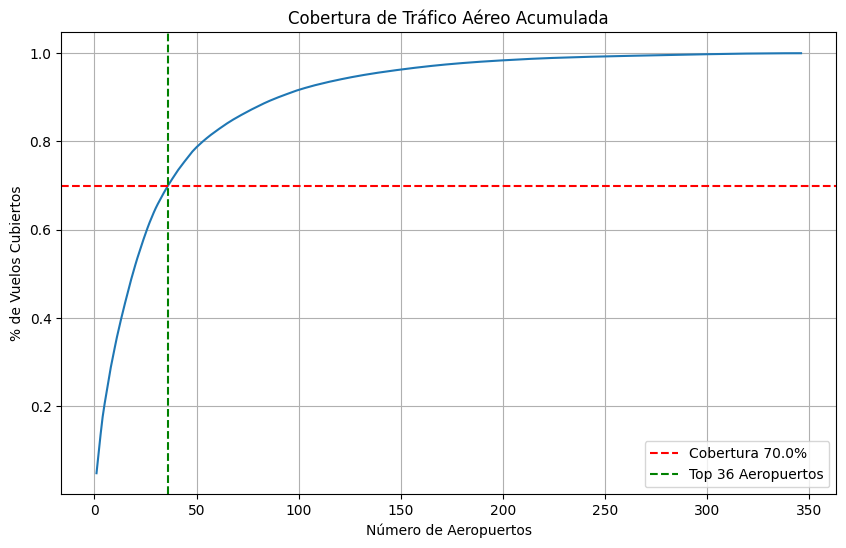

In [ ]:
# Calculamos la frecuencia de cada aeropuerto
conteos = X_train_proc['aeropuerto_origen'].value_counts()

# Calculamos el porcentaje acumulado (Cumulative Percentage)
acumulado = conteos.cumsum() / conteos.sum()
COBERTURA_OBJETIVO = 0.70

# Encontramos cuántos aeropuertos se necesitan para llegar a ese 85%
n_top = np.searchsorted(acumulado, COBERTURA_OBJETIVO) + 1
print(f"Para cubrir el {COBERTURA_OBJETIVO*100}% del tráfico, necesitas el Top {n_top} aeropuertos.")
print(f"Esto dejaría fuera a {len(conteos) - n_top} aeropuertos pequeños (categoría 'Otros').")

# Visualización para justificar tu decisión (El gráfico de Pareto)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(conteos) + 1), acumulado.values)
plt.axhline(y=COBERTURA_OBJETIVO, color='r', linestyle='--', label=f'Cobertura {COBERTURA_OBJETIVO*100}%')
plt.axvline(x=n_top, color='g', linestyle='--', label=f'Top {n_top} Aeropuertos')
plt.title('Cobertura de Tráfico Aéreo Acumulada')
plt.xlabel('Número de Aeropuertos')
plt.ylabel('% de Vuelos Cubiertos')
plt.legend()
plt.grid(True)
plt.show()

Para cubrir el 70.0% del tráfico, necesitas el Top 37 aeropuertos.
Esto dejaría fuera a 309 aeropuertos pequeños (categoría 'Otros').


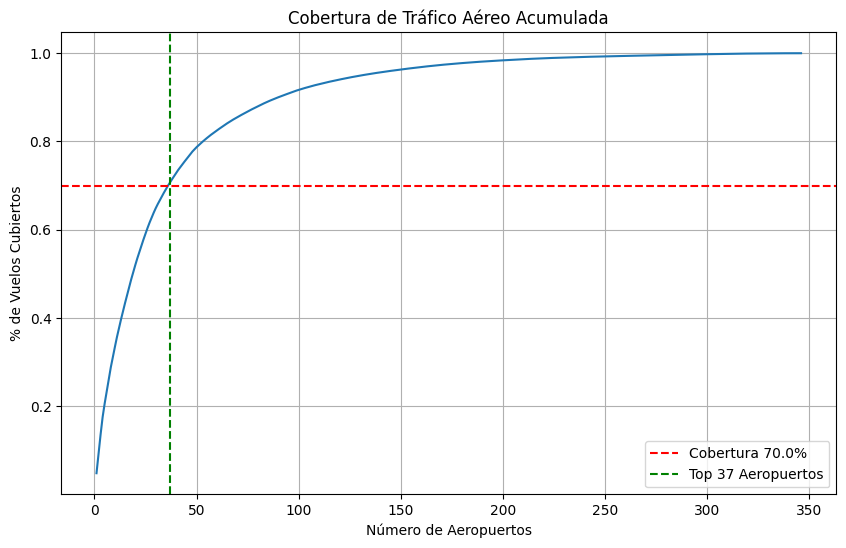

In [ ]:
# Calculamos la frecuencia de cada aeropuerto
conteos = X_train_proc['aeropuerto_destino'].value_counts()

# Calculamos el porcentaje acumulado (Cumulative Percentage)
acumulado = conteos.cumsum() / conteos.sum()
COBERTURA_OBJETIVO = 0.7

# Encontramos cuántos aeropuertos se necesitan para llegar a ese 70%
n_top = np.searchsorted(acumulado, COBERTURA_OBJETIVO) + 1
print(f"Para cubrir el {COBERTURA_OBJETIVO*100}% del tráfico, necesitas el Top {n_top} aeropuertos.")
print(f"Esto dejaría fuera a {len(conteos) - n_top} aeropuertos pequeños (categoría 'Otros').")

# Visualización para justificar tu decisión (El gráfico de Pareto)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(conteos) + 1), acumulado.values)
plt.axhline(y=COBERTURA_OBJETIVO, color='r', linestyle='--', label=f'Cobertura {COBERTURA_OBJETIVO*100}%')
plt.axvline(x=n_top, color='g', linestyle='--', label=f'Top {n_top} Aeropuertos')
plt.title('Cobertura de Tráfico Aéreo Acumulada')
plt.xlabel('Número de Aeropuertos')
plt.ylabel('% de Vuelos Cubiertos')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def get_top_list(df, col, n=36):
    return df[col].value_counts().head(n).index.tolist()

top_origen = get_top_list(X_train_proc, 'aeropuerto_origen')
top_destino = get_top_list(X_train_proc, 'aeropuerto_destino')

# Función para aplicar el reemplazo
def aplicar_top_n(df, col, top_list):
    # Si el valor no está en la lista top, se reemplaza por 'Other'
    return df[col].apply(lambda x: x if x in top_list else 'Other')

# Aplicamos la transformación a LOS TRES sets usando la lista de TRAIN
for df in [X_train_proc, X_val_proc, X_test_proc]:
    df['aeropuerto_origen'] = aplicar_top_n(df, 'aeropuerto_origen', top_origen)
    df['aeropuerto_destino'] = aplicar_top_n(df, 'aeropuerto_destino', top_destino)


In [ ]:
X_train_proc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6565266 entries, 11452 to 6570182
Data columns (total 18 columns):
 #   Column              Dtype  
---  ------              -----  
 0   fin_de_semana       int64  
 1   distancia_millas    float64
 2   tiempo_programado   float64
 3   aerolinea           object 
 4   aeropuerto_origen   object 
 5   aeropuerto_destino  object 
 6   estado_origen       object 
 7   estado_destino      object 
 8   mes_sin             float64
 9   mes_cos             float64
 10  dia_semana_sin      float64
 11  dia_semana_cos      float64
 12  dia_mes_sin         float64
 13  dia_mes_cos         float64
 14  hora_salida_sin     float64
 15  hora_salida_cos     float64
 16  minuto_salida_sin   float64
 17  minuto_salida_cos   float64
dtypes: float64(12), int64(1), object(5)
memory usage: 951.7+ MB


In [ ]:
# Submuestreo para viabilidad computacional
sample = X_train_proc.sample(n=200_000, random_state=42)

# Solo variables numéricas
sample_num = sample.select_dtypes(include=['float64', 'int64'])

# Matriz de correlación (Pearson)
corr = sample_num.corr()


In [ ]:
corr_rounded = corr.round(3)
corr_rounded


,fin_de_semana,distancia_millas,tiempo_programado,mes_sin,mes_cos,dia_semana_sin,dia_semana_cos,dia_mes_sin,dia_mes_cos,hora_salida_sin,hora_salida_cos,minuto_salida_sin,minuto_salida_cos
fin_de_semana,1.000,0.010,0.009,0.001,0.002,-0.321,0.717,-0.002,-0.001,-0.003,0.003,-0.001,-0.000
distancia_millas,0.010,1.000,0.984,0.007,-0.010,-0.009,0.006,-0.002,0.000,0.035,0.033,-0.009,0.020
tiempo_programado,0.009,0.984,1.000,0.017,0.005,-0.007,0.005,-0.001,0.001,0.037,0.029,-0.006,0.021
mes_sin,0.001,0.007,0.017,1.000,-0.018,-0.004,0.002,0.004,0.002,-0.003,0.010,-0.003,0.000
mes_cos,0.002,-0.010,0.005,-0.018,1.000,0.012,0.012,0.041,0.025,0.011,-0.024,-0.002,0.002
dia_semana_sin,-0.321,-0.009,-0.007,-0.004,0.012,1.000,0.035,0.002,0.004,0.003,-0.009,0.003,-0.001
dia_semana_cos,0.717,0.006,0.005,0.002,0.012,0.035,1.000,0.002,0.001,-0.006,0.010,-0.000,-0.004
dia_mes_sin,-0.002,-0.002,-0.001,0.004,0.041,0.002,0.002,1.000,0.009,0.003,-0.007,0.003,0.004
dia_mes_cos,-0.001,0.000,0.001,0.002,0.025,0.004,0.001,0.009,1.000,-0.002,-0.001,0.002,0.000
hora_salida_sin,-0.003,0.035,0.037,-0.003,0.011,0.003,-0.006,0.003,-0.002,1.000,-0.217,0.042,0.064


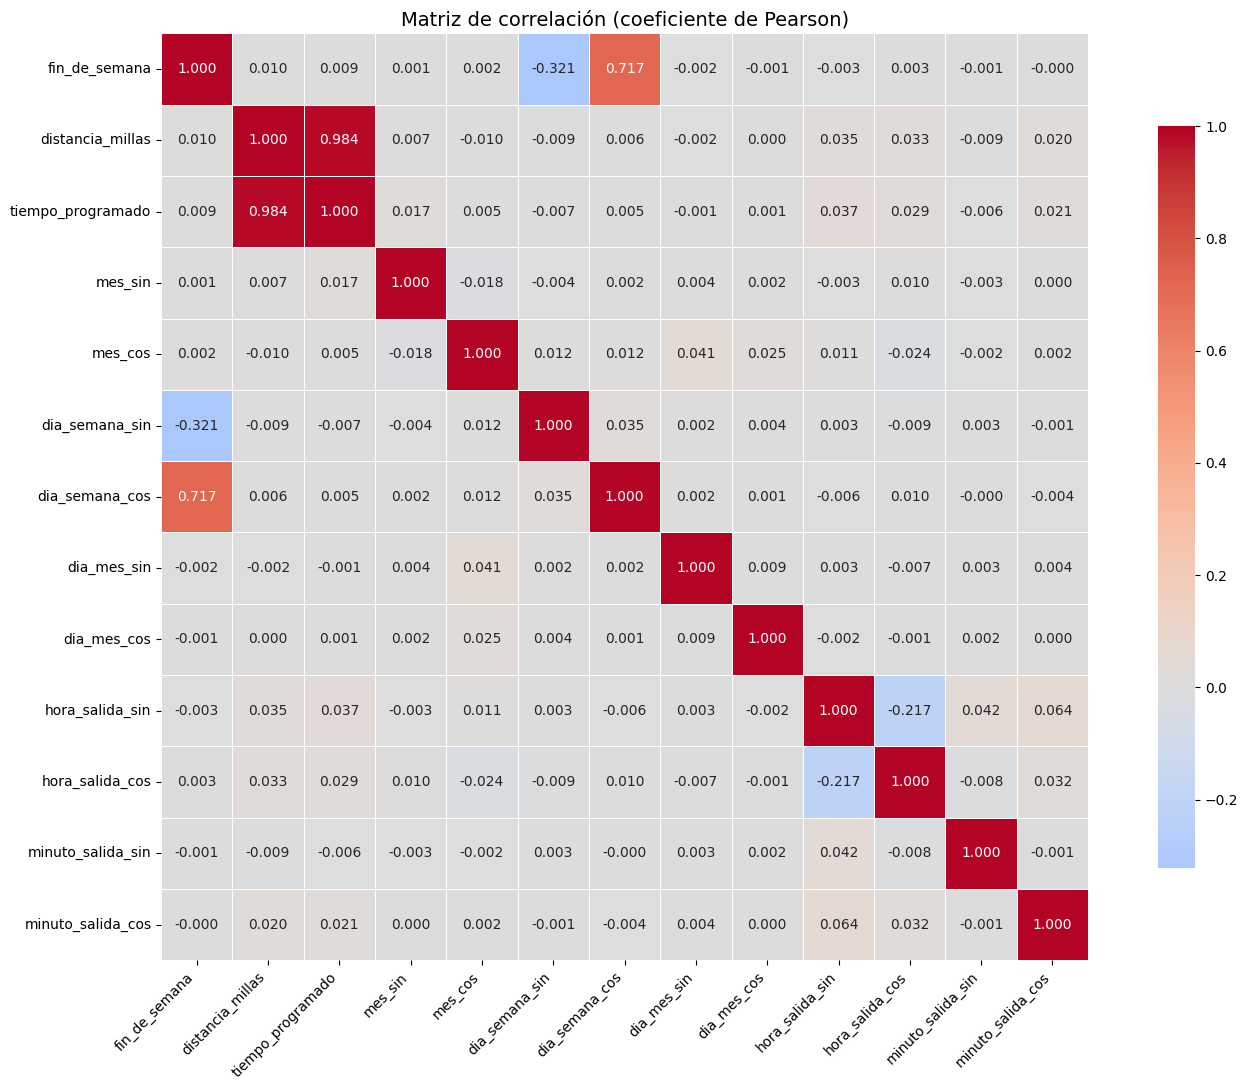

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 11))

sns.heatmap(
    corr,
    annot=True,              # ← muestra los números
    fmt=".3f",               # ← 3 decimales (estándar académico)
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title(
    "Matriz de correlación (coeficiente de Pearson)",
    fontsize=14
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


In [ ]:
X_train_proc['fin_de_semana'] = (X_train_proc['fin_de_semana'] > 0).astype(int)
X_val_proc['fin_de_semana']   = (X_val_proc['fin_de_semana'] > 0).astype(int)
X_test_proc['fin_de_semana']  = (X_test_proc['fin_de_semana'] > 0).astype(int)
cols_binarias=['fin_de_semana']

C. ESCALADO NUMÉRICO (STANDARD SCALER)

In [ ]:
# Las redes neuronales requieren variables escaladas (mean=0, std=1)
# Fuente: Zheng & Casari destacan la importancia de esto para modelos suaves [1]
cols_numericas = ['distancia_millas', 'tiempo_programado']


D. ONE-HOT ENCODING FINAL

In [ ]:
columnas_estado_a_borrar = ['estado_origen', 'estado_destino']

for df in [X_train_proc, X_val_proc, X_test_proc]:
    df.drop(columns=columnas_estado_a_borrar, inplace=True)
categorical_columns = [
    'aerolinea',
    'aeropuerto_origen',
    'aeropuerto_destino'
]


In [ ]:

columnas_ciclicas_a_borrar = [
    'dia_mes_sin', 'dia_mes_cos',
    'minuto_salida_sin', 'minuto_salida_cos'
]
for df in [X_train_proc, X_val_proc, X_test_proc]:
    df.drop(columns=columnas_ciclicas_a_borrar, inplace=True)


ciclicas_a_conservar = [
    'mes_sin', 'mes_cos',
    'dia_semana_sin', 'dia_semana_cos',
    'hora_salida_sin', 'hora_salida_cos'
]



In [ ]:
X_train_proc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6565266 entries, 11452 to 6570182
Data columns (total 12 columns):
 #   Column              Dtype  
---  ------              -----  
 0   fin_de_semana       int64  
 1   distancia_millas    float64
 2   tiempo_programado   float64
 3   aerolinea           object 
 4   aeropuerto_origen   object 
 5   aeropuerto_destino  object 
 6   mes_sin             float64
 7   mes_cos             float64
 8   dia_semana_sin      float64
 9   dia_semana_cos      float64
 10  hora_salida_sin     float64
 11  hora_salida_cos     float64
dtypes: float64(8), int64(1), object(3)
memory usage: 651.2+ MB


In [ ]:
categorical_columns = ['aerolinea', 'aeropuerto_origen', 'aeropuerto_destino']

print("Valores únicos de columnas categóricas")
for column in categorical_columns:
  print(f"{column}: {X_train_proc[column].nunique()}")

Valores únicos de columnas categóricas
aerolinea: 15
aeropuerto_origen: 37
aeropuerto_destino: 37


In [ ]:
X_train_proc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6565266 entries, 11452 to 6570182
Data columns (total 12 columns):
 #   Column              Dtype  
---  ------              -----  
 0   fin_de_semana       int64  
 1   distancia_millas    float64
 2   tiempo_programado   float64
 3   aerolinea           object 
 4   aeropuerto_origen   object 
 5   aeropuerto_destino  object 
 6   mes_sin             float64
 7   mes_cos             float64
 8   dia_semana_sin      float64
 9   dia_semana_cos      float64
 10  hora_salida_sin     float64
 11  hora_salida_cos     float64
dtypes: float64(8), int64(1), object(3)
memory usage: 651.2+ MB


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[

        # 1. Numéricas continuas → escalar
        ('num',
         StandardScaler(),
         cols_numericas),

        # 2. Categóricas → One-Hot (disperso, eficiente)
        ('cat',
         OneHotEncoder(
             handle_unknown='ignore',
             sparse_output=True
         ),
         categorical_columns),

        # 3. Cíclicas → pasar tal cual (YA están bien codificadas)
        ('ciclicas',
         'passthrough',
         ciclicas_a_conservar),

        # 4. Binarias → pasar tal cual
        ('binarias',
         'passthrough',
         cols_binarias)
    ],
    remainder='drop'
)


In [ ]:
# 3. Transformación Final
# Ajustamos SOLO en el set de entrenamiento
print("Ajustando preprocesador en Train...")
X_train_final = preprocessor.fit_transform(X_train_proc)

# Aplicamos la transformación a Validación y Test
print("Transformando Val y Test...")
X_val_final = preprocessor.transform(X_val_proc)
X_test_final = preprocessor.transform(X_test_proc)


# 4. Verificación de Dimensiones
print("-" * 30)
print(f"Dimensiones Finales (Filas, Features):")
print(f"Train: {X_train_final.shape}")
print(f"Val:   {X_val_final.shape}")
print(f"Test:  {X_test_final.shape}")
print("-" * 30)

Ajustando preprocesador en Train...
Transformando Val y Test...
------------------------------
Dimensiones Finales (Filas, Features):
Train: (6565266, 98)
Val:   (200000, 98)
Test:  (200000, 98)
------------------------------


In [ ]:
import scipy.sparse
import numpy as np
import joblib  # Para guardar el pipeline
import os


In [ ]:
# Crear una carpeta para organizar los archivos
os.makedirs('data_processed', exist_ok=True)

# 1. Guardar las matrices X (Features) en formato comprimido .npz
# Esto es muy eficiente para matrices con muchos ceros (One-Hot)
print("Guardando matrices X...")
scipy.sparse.save_npz('data_processed/X_train.npz', X_train_final)
scipy.sparse.save_npz('data_processed/X_val.npz', X_val_final)
scipy.sparse.save_npz('data_processed/X_test.npz', X_test_final)

# 2. Guardar los vectores y (Targets) en formato .npy
# Asumiendo que y_train, etc. son Pandas Series, las convertimos a numpy
print("Guardando vectores y...")
np.save('data_processed/y_train.npy', y_train.to_numpy())
np.save('data_processed/y_val.npy', y_val.to_numpy())
np.save('data_processed/y_test.npy', y_test.to_numpy())

print("¡Datos guardados exitosamente!")

Guardando matrices X...
Guardando vectores y...
¡Datos guardados exitosamente!


In [ ]:
# 3. Guardar el objeto de preprocesamiento (Pipeline)
print("Guardando el preprocesador...")
joblib.dump(preprocessor, 'data_processed/preprocessor.joblib')

print("Pipeline guardado. Ahora puedes reiniciar sin perder nada.")

Guardando el preprocesador...
Pipeline guardado. Ahora puedes reiniciar sin perder nada.




```
import scipy.sparse
import numpy as np
import joblib

# 1. Cargar Features
X_train = scipy.sparse.load_npz('data_processed/X_train.npz')
X_val = scipy.sparse.load_npz('data_processed/X_val.npz')
X_test = scipy.sparse.load_npz('data_processed/X_test.npz')

# 2. Cargar Targets
y_train = np.load('data_processed/y_train.npy', allow_pickle=True)
y_val = np.load('data_processed/y_val.npy', allow_pickle=True)
y_test = np.load('data_processed/y_test.npy', allow_pickle=True)

# 3. Cargar el Preprocesador (para usarlo en nuevos datos individuales)
preprocessor = joblib.load('data_processed/preprocessor.joblib')

print("Datos cargados. Dimensiones de train:", X_train.shape)
```



In [ ]:
from google.colab import drive
import os
import joblib
import scipy.sparse
import numpy as np

# 1. Montar Google Drive
drive.mount('/content/drive')

# 2. Definir ruta de almacenamiento
# Creamos una carpeta específica para mantener el orden
base_path = '/content/drive/My Drive/Proyecto_Vuelos_Delay/'
os.makedirs(base_path, exist_ok=True)

print(f"Guardando datos en: {base_path}")

# 3. Guardar las Matrices de Características (X)
# Usamos .npz comprimido porque X es una matriz dispersa (sparse matrix)
# Esto es vital para no saturar el almacenamiento de Drive con ceros innecesarios.
print("Guardando X_train, X_val, X_test...")
scipy.sparse.save_npz(os.path.join(base_path, 'X_train.npz'), X_train_final)
scipy.sparse.save_npz(os.path.join(base_path, 'X_val.npz'), X_val_final)
scipy.sparse.save_npz(os.path.join(base_path, 'X_test.npz'), X_test_final)

# 4. Guardar los Vectores Objetivo (y)
# Los guardamos como arrays de Numpy estándar
print("Guardando y_train, y_val, y_test...")
np.save(os.path.join(base_path, 'y_train.npy'), y_train.to_numpy())
np.save(os.path.join(base_path, 'y_val.npy'), y_val.to_numpy())
np.save(os.path.join(base_path, 'y_test.npy'), y_test.to_numpy())

# 5. Guardar el Pipeline de Preprocesamiento (CRÍTICO)
# Esto guarda el objeto que "aprendió" los promedios para escalar y
# el vocabulario de tus aeropuertos (OneHotEncoder).
print("Guardando el preprocesador...")
joblib.dump(preprocessor, os.path.join(base_path, 'preprocessor.joblib'))

print("¡Proceso completado! Tus datos están seguros en Drive.")

Mounted at /content/drive
Guardando datos en: /content/drive/My Drive/Proyecto_Vuelos_Delay/
Guardando X_train, X_val, X_test...


NameError: name 'X_train_final' is not defined

In [ ]:
feature_names = preprocessor.get_feature_names_out()


In [ ]:
from google.colab import drive
import os
import joblib
import scipy.sparse
import numpy as np

# 1. Montar Drive
drive.mount('/content/drive')

# 2. Definir la ruta donde guardaste los archivos
base_path = '/content/drive/My Drive/Proyecto_Vuelos_Delay/'

print("Cargando datos procesados desde Drive...")

# 3. Cargar Features (X)
X_train = scipy.sparse.load_npz(os.path.join(base_path, 'X_train.npz'))
X_val = scipy.sparse.load_npz(os.path.join(base_path, 'X_val.npz'))
X_test = scipy.sparse.load_npz(os.path.join(base_path, 'X_test.npz'))

# 4. Cargar Targets (y)
y_train = np.load(os.path.join(base_path, 'y_train.npy'), allow_pickle=True)
y_val = np.load(os.path.join(base_path, 'y_val.npy'), allow_pickle=True)
y_test = np.load(os.path.join(base_path, 'y_test.npy'), allow_pickle=True)

# 5. Cargar el Preprocesador (opcional, útil si vas a predecir datos nuevos individuales)
preprocessor = joblib.load(os.path.join(base_path, 'preprocessor.joblib'))

print(f"Datos listos.")
print(f"Dimensiones X_train: {X_train.shape}")
print(f"Dimensiones y_train: {y_train.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cargando datos procesados desde Drive...
Datos listos.
Dimensiones X_train: (6565266, 98)
Dimensiones y_train: (6565266,)


DE AQUI SEPARE

```
# Tiene formato de código
```



In [ ]:
y_train = pd.Series(y_train)
y_val = pd.Series(y_val)
y_test = pd.Series(y_test)

NameError: name 'pd' is not defined

In [ ]:
y_train

,0
0,0
1,0
2,0
3,0
4,0
...,...
6565261,0
6565262,0
6565263,0
6565264,0


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
def obtener_distribucion(y_data, nombre_set):
    """
    Calcula conteo y porcentaje de la variable objetivo.

    Parámetros
    ----------
    y_data : pd.Series
        Variable objetivo binaria (0/1)
    nombre_set : str
        Nombre del conjunto (Train / Validation / Test)

    Retorna
    -------
    pd.DataFrame
        DataFrame en formato tidy (una variable = una columna)
    """
    conteo = y_data.value_counts().sort_index()
    porcentaje = y_data.value_counts(normalize=True).sort_index() * 100

    df = pd.DataFrame({
        'vuelo_retrasado': conteo.index,     # Variable objetivo explícita
        'Conteo': conteo.values,
        'Porcentaje': porcentaje.values,
        'Set': nombre_set
    })

    return df


# ============================================================
# 1. Cálculo de distribuciones
# ============================================================
dist_train = obtener_distribucion(y_train, 'Train')
dist_val   = obtener_distribucion(y_val, 'Validation')
dist_test  = obtener_distribucion(y_test, 'Test')

# Unir todo
dist_total = pd.concat(
    [dist_train, dist_val, dist_test],
    ignore_index=True
)

# Mostrar tabla
print("Distribución de Clases (0 = A tiempo, 1 = Retrasado)")
print("-" * 60)
print(dist_total)
print("-" * 60)


# ============================================================
# 2. Visualización
# ============================================================
plt.figure(figsize=(10, 6))

sns.barplot(
    data=dist_total,
    x='Set',
    y='Porcentaje',
    hue='vuelo_retrasado'
)

plt.title('Distribución porcentual de retrasos por conjunto')
plt.xlabel('Conjunto de datos')
plt.ylabel('Porcentaje (%)')
plt.legend(title='Clase\n0 = A tiempo\n1 = Retrasado')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 3. Cálculo del desbalance (solo TRAIN, como corresponde)
# ============================================================
n_neg = dist_train.loc[dist_train['vuelo_retrasado'] == 0, 'Conteo'].values[0]
n_pos = dist_train.loc[dist_train['vuelo_retrasado'] == 1, 'Conteo'].values[0]

ratio_desbalance = n_neg / n_pos

print(f"Desbalance en TRAIN (Negativos / Positivos): {ratio_desbalance:.2f}")
print(
    f"Recomendación práctica:\n"
    f"class_weight = {{0: 1, 1: {ratio_desbalance:.2f}}}"
)

AttributeError: 'numpy.ndarray' object has no attribute 'value_counts'

In [ ]:
# Asumiendo que y_train es tu Pandas Series
n_pos = (y_train == 1).sum()
n_neg = (y_train == 0).sum()

# Fórmula recomendada para XGBoost/LightGBM
scale_pos_weight = n_neg / n_pos

print(f"--- Diagnóstico de Balance ---")
print(f"Vuelos Retrasados (1): {n_pos}")
print(f"Vuelos A Tiempo (0): {n_neg}")
print(f"Factor de corrección calculado: {scale_pos_weight:.2f}")
print("Este valor obligará al modelo a prestar X veces más atención a los retrasos.")


--- Diagnóstico de Balance ---
Vuelos Retrasados (1): 1298135
Vuelos A Tiempo (0): 1298135
Factor de corrección calculado: 1.00
Este valor obligará al modelo a prestar X veces más atención a los retrasos.


In [ ]:

from sklearn.feature_selection import SelectFromModel
from lightgbm import LGBMClassifier

print("\nIniciando selección de características basada en importancia...")

# Usamos LightGBM porque es muy rápido y maneja bien matrices dispersas
# Configuramos n_estimators bajo (100) solo para obtener la importancia rápido
selector_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, # Usamos el peso calculado arriba
    n_jobs=-1,
    verbose=-1
)

# Ajustamos el selector (Solo aprende qué variables importan)
selector_model.fit(X_train, y_train)

# Creamos el objeto selector que filtrará las columnas
# 'median' selecciona las variables cuya importancia es mayor a la mediana
fs = SelectFromModel(selector_model, threshold='median', prefit=True)

# Aplicamos la transformación (El "Tratamiento" real)
X_train = fs.transform(X_train)
X_test = fs.transform(X_test) # ¡Importante! Aplicar lo mismo al test
# Si tienes X_val, aplícalo también:



Iniciando selección de características basada en importancia...


In [ ]:
X_val = fs.transform(X_val)

In [ ]:

print(f"Columnas originales: {X_train.shape[1]}")
print(f"Columnas después del tratamiento: {X_train.shape[1]}")
print("¡Reducción de dimensionalidad completada!")

Columnas originales: 51
Columnas después del tratamiento: 51
¡Reducción de dimensionalidad completada!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
def obtener_distribucion(y_data, nombre_set):
    """
    Calcula conteo y porcentaje de la variable objetivo.

    Parámetros
    ----------
    y_data : pd.Series
        Variable objetivo binaria (0/1)
    nombre_set : str
        Nombre del conjunto (Train / Validation / Test)

    Retorna
    -------
    pd.DataFrame
        DataFrame en formato tidy (una variable = una columna)
    """
    conteo = y_data.value_counts().sort_index()
    porcentaje = y_data.value_counts(normalize=True).sort_index() * 100

    df = pd.DataFrame({
        'vuelo_retrasado': conteo.index,     # Variable objetivo explícita
        'Conteo': conteo.values,
        'Porcentaje': porcentaje.values,
        'Set': nombre_set
    })

    return df


# ============================================================
# 1. Cálculo de distribuciones
# ============================================================
dist_train = obtener_distribucion(y_train, 'Train')
dist_val   = obtener_distribucion(y_val, 'Validation')
dist_test  = obtener_distribucion(y_test, 'Test')

# Unir todo
dist_total = pd.concat(
    [dist_train, dist_val, dist_test],
    ignore_index=True
)

# Mostrar tabla
print("Distribución de Clases (0 = A tiempo, 1 = Retrasado)")
print("-" * 60)
print(dist_total)
print("-" * 60)


# ============================================================
# 2. Visualización
# ============================================================
plt.figure(figsize=(10, 6))

sns.barplot(
    data=dist_total,
    x='Set',
    y='Porcentaje',
    hue='vuelo_retrasado'
)

plt.title('Distribución porcentual de retrasos por conjunto')
plt.xlabel('Conjunto de datos')
plt.ylabel('Porcentaje (%)')
plt.legend(title='Clase\n0 = A tiempo\n1 = Retrasado')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 3. Cálculo del desbalance (solo TRAIN, como corresponde)
# ============================================================
n_neg = dist_train.loc[dist_train['vuelo_retrasado'] == 0, 'Conteo'].values[0]
n_pos = dist_train.loc[dist_train['vuelo_retrasado'] == 1, 'Conteo'].values[0]

ratio_desbalance = n_neg / n_pos

print(f"Desbalance en TRAIN (Negativos / Positivos): {ratio_desbalance:.2f}")
print(
    f"Recomendación práctica:\n"
    f"class_weight = {{0: 1, 1: {ratio_desbalance:.2f}}}"
)

AttributeError: 'numpy.ndarray' object has no attribute 'value_counts'

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.metrics import AUC, Precision, Recall

# 1. Obtener la dimensión de entrada (número de columnas en X_train)
#input_dim = X_train.shape[1]
input_dim = X_train_selected.shape[1]
print(f"Dimensiones de entrada (features): {input_dim}")


In [ ]:
import tensorflow as tf
import keras


keras.backend.clear_session()
tf.compat.v1.reset_default_graph()

import gc
gc.collect()

# 2. Definir la arquitectura Secuencial
model = Sequential()

# --- Capa de Entrada y 1ra Capa Oculta ---
# Empezamos con una capa ancha. He normal (kernel_initializer) es buena para ReLU.
model.add(Dense(64, input_dim=input_dim, activation='relu',   kernel_regularizer=regularizers.l2(0.01)))
model.add(BatchNormalization()) # Estabiliza el aprendizaje
model.add(Dropout(0.3))         # Apaga el 30% de las neuronas para evitar overfitting

# --- 2da Capa Oculta ---
# Reducimos gradualmente el número de neuronas (patrón de embudo)
#kernel_initializer='he_normal' ,
model.add(Dense(64, activation='relu',  kernel_regularizer=regularizers.l2(0.01)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# --- 3ra Capa Oculta ---
model.add(Dense(64, activation='relu',  kernel_regularizer=regularizers.l2(0.01)))
model.add(BatchNormalization())
model.add(Dropout(0.2))

# --- Capa de Salida ---
# 1 neurona, activación Sigmoid para probabilidad binaria (0 a 1)
model.add(Dense(1, activation='sigmoid'))

# 3. Compilar el Modelo
# Optimizer: Adam es el estándar general por su eficiencia [11].
# Loss: 'binary_crossentropy' es obligatorio para clasificación binaria [12].
# Metrics: Incluimos Precision y Recall porque los retrasos suelen ser clase minoritaria.

optimizer = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)

model.compile(optimizer=optimizer,
              loss='binary_crossentropy',
              metrics=[
                  'accuracy', AUC(name='auc_pr', curve='PR')
              ])
# Resumen de la red
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,417 (48.50 KB)

 Trainable params: 12,033 (47.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
from tensorflow.keras.callbacks import BackupAndRestore
backup_callback = BackupAndRestore(
    backup_dir='/content/drive/My Drive/Proyecto_Vuelos_Delay/backup_training'
)


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 4. Definir Callbacks con min_delta
# min_delta=0.001 significa que si la mejora es menor a 0.001, no cuenta como mejora.
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        min_delta=0.0001,  # <--- Exige una mejora mínima para continu
        verbose=1
    ),
    ModelCheckpoint(
        filepath='/content/drive/My Drive/Proyecto_Vuelos_Delay/best_model.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    backup_callback
]


In [ ]:
import numpy as np

# 1. Calcular los pesos automáticamente para ser precisos
# Fórmula: n_muestras / (n_clases * conteo_clase)
# Esto balancea "perfectamente" las clases ante los ojos del modelo.
from sklearn.utils import class_weight

pesos_calculados = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Convertir a diccionario para Keras: {0: peso_0, 1: peso_1}
class_weights_dict = dict(enumerate(pesos_calculados))

print(f"Pesos calculados: {class_weights_dict}")
# Deberías ver algo como {0: 0.62, 1: 2.52}
# (La proporción relativa se mantiene: 2.52 / 0.62 ≈ 4.06)

Pesos calculados: {0: np.float64(0.6232298000562355), 1: np.float64(2.5287300627438594)}


In [ ]:
import numpy as np
import tensorflow as tf

class SparseDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, x_set, y_set, batch_size):
        self.x, self.y = x_set, y_set
        self.batch_size = batch_size
        # CORRECCIÓN: Usamos .shape para obtener solo el número de filas (entero)
        self.indices = np.arange(x_set.shape)

    def __len__(self):
        # CORRECCIÓN: Usamos .shape para calcular cuántos batches hay
        return int(np.ceil(self.x.shape / self.batch_size))

    def __getitem__(self, idx):
        # 1. Obtener índices del batch actual
        inds = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]

        # 2. Extraer el batch de la matriz dispersa
        # Nota: Al indexar una matriz sparse con una lista de enteros, se preserva el formato sparse
        batch_x = self.x[inds]

        # 3. Manejo seguro de y_set (si es Pandas Series o Numpy array)
        if hasattr(self.y, 'iloc'):
            batch_y = self.y.iloc[inds]
        else:
            batch_y = self.y[inds]

        # 4. Convertir SOLO este batch a denso (Dense Array)
        # Esto permite que la red neuronal procese los datos sin saturar la RAM
        batch_x_dense = batch_x.toarray()

        return batch_x_dense, np.array(batch_y)

# --- Instanciar y Entrenar ---

# Instanciar generadores con el código corregido
training_generator = SparseDataGenerator(X_train_selected[0], y_train, batch_size=2048)
validation_generator = SparseDataGenerator(X_val_selected[0], y_val, batch_size=2048)

print("Iniciando entrenamiento de la Red Neuronal (MLP)...")

history = model.fit(
    training_generator,
    validation_data=validation_generator,
    epochs=50,
    callbacks=callbacks,             # Tus callbacks (EarlyStopping)
    class_weight=class_weights_dict, # Tu diccionario de pesos para el desbalance
    verbose=1
)

TypeError: arange: scalar arguments expected instead of a tuple.

In [ ]:
history = model.fit(
    X_train_selected,
    y_train,
    validation_data=(X_val_selected, y_val),
    epochs=50,
    batch_size=2048,
    callbacks=callbacks,
    class_weight=class_weights_dict,
    verbose=1
)

Epoch 1/50


ValueError: Creating variables on a non-first call to a function decorated with tf.function.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# probabilidades entre 0 y 1 (capa Sigmoid)
y_pred_probs = model.predict(X_test)

# Convertimos probabilidades a clases (0 o 1) usando un umbral de 0.5
y_pred_classes = (y_pred_probs > 0.5).astype(int)

print("Predicciones generadas con éxito.")

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
Predicciones generadas con éxito.


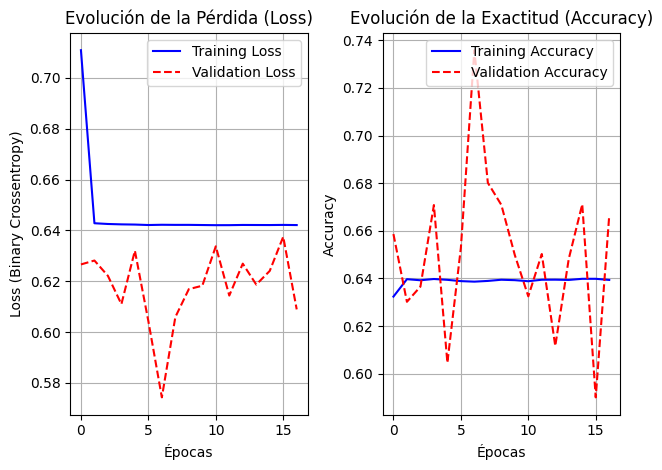

In [ ]:

# --- Gráfica 1: Loss vs Val_Loss ---
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red', linestyle='--')
plt.title('Evolución de la Pérdida (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Loss (Binary Crossentropy)')
plt.legend()
plt.grid(True)

# --- Gráfica 2: Accuracy vs Val_Accuracy ---
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', linestyle='--')
plt.title('Evolución de la Exactitud (Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# Interpretación impresa
print("\n--- INTERPRETACIÓN DE CURVAS ---")
print("1. Si la línea ROJA (Val) empieza a subir mientras la AZUL (Train) baja: Hay Overfitting.")
print("2. Si ambas líneas están muy separadas: El modelo memoriza datos pero no generaliza.")
print("3. El punto ideal es donde la línea roja alcanza su valor mínimo.")


--- INTERPRETACIÓN DE CURVAS ---
1. Si la línea ROJA (Val) empieza a subir mientras la AZUL (Train) baja: Hay Overfitting.
2. Si ambas líneas están muy separadas: El modelo memoriza datos pero no generaliza.
3. El punto ideal es donde la línea roja alcanza su valor mínimo.



REPORTE DE CLASIFICACIÓN (MÉTRICAS NUMÉRICAS)
               precision    recall  f1-score   support

 A tiempo (0)       0.79      0.71      0.75    146076
Retrasado (1)       0.39      0.50      0.44     53924

     accuracy                           0.65    200000
    macro avg       0.59      0.61      0.59    200000
 weighted avg       0.69      0.65      0.67    200000



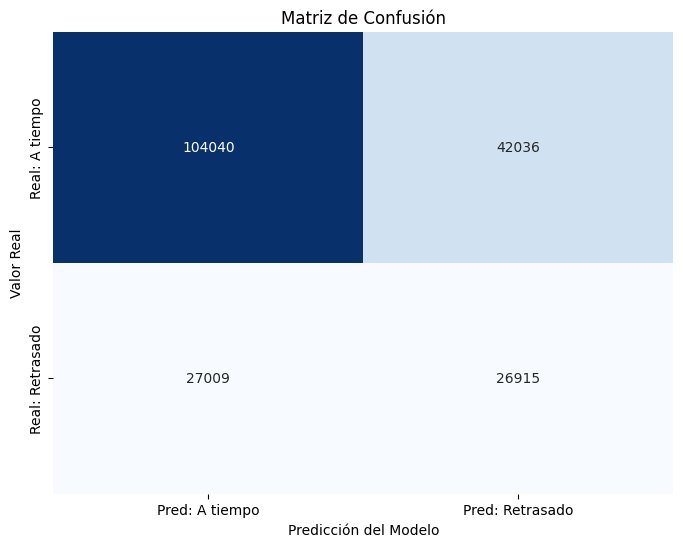


--- INTERPRETACIÓN DE LA MATRIZ ---
Vuelos A TIEMPO predichos correctamente (TN): 104040
Vuelos RETRASADOS predichos correctamente (TP): 26915 (¡Este es tu éxito detectando problemas!)
Falsas Alarmas (FP): 42036 (Predijiste retraso, pero llegó bien)
Retrasos NO detectados (FN): 27009 (El error más costoso: predijiste a tiempo, pero se retrasó)


In [ ]:
# Calcular la matriz
cm = confusion_matrix(y_test, y_pred_classes)

# --- Formato Print (Reporte de Clasificación) ---
print("\n" + "="*50)
print("REPORTE DE CLASIFICACIÓN (MÉTRICAS NUMÉRICAS)")
print("="*50)
print(classification_report(y_test, y_pred_classes, target_names=['A tiempo (0)', 'Retrasado (1)']))

# --- Formato Plot (Mapa de Calor) ---
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred: A tiempo', 'Pred: Retrasado'],
            yticklabels=['Real: A tiempo', 'Real: Retrasado'])
plt.title('Matriz de Confusión')
plt.ylabel('Valor Real')
plt.xlabel('Predicción del Modelo')
plt.show()

# Interpretación impresa específica para tu problema
tn, fp, fn, tp = cm.ravel()
print(f"\n--- INTERPRETACIÓN DE LA MATRIZ ---")
print(f"Vuelos A TIEMPO predichos correctamente (TN): {tn}")
print(f"Vuelos RETRASADOS predichos correctamente (TP): {tp} (¡Este es tu éxito detectando problemas!)")
print(f"Falsas Alarmas (FP): {fp} (Predijiste retraso, pero llegó bien)")
print(f"Retrasos NO detectados (FN): {fn} (El error más costoso: predijiste a tiempo, pero se retrasó)")


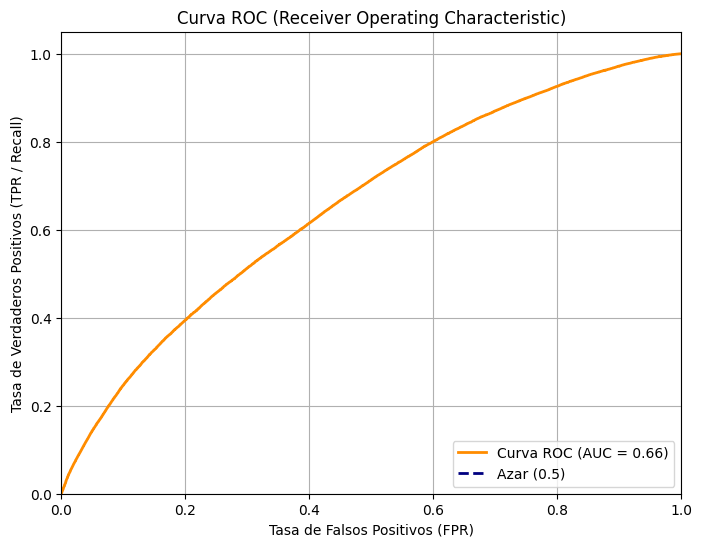


--- INTERPRETACIÓN DE ROC/AUC ---
El Área Bajo la Curva (AUC) es: 0.66
>> REGULAR: El modelo es mejor que el azar, pero necesita mejoras.


In [ ]:
# Calcular curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([7], color='navy', lw=2, linestyle='--', label='Azar (0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
plt.title('Curva ROC (Receiver Operating Characteristic)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Interpretación en texto
print("\n--- INTERPRETACIÓN DE ROC/AUC ---")
print(f"El Área Bajo la Curva (AUC) es: {roc_auc:.2f}")
if roc_auc > 0.8:
    print(">> EXCELENTE: El modelo distingue muy bien entre vuelos retrasados y a tiempo.")
elif roc_auc > 0.7:
    print(">> BUENO: El modelo tiene una capacidad aceptable de discriminación.")
elif roc_auc > 0.5:
    print(">> REGULAR: El modelo es mejor que el azar, pero necesita mejoras.")
else:
    print(">> MALO: El modelo no está aprendiendo nada útil (o está invirtiendo las clases).")


Y

In [ ]:
import xgboost as xgb
import numpy as np

# 1. Calcular scale_pos_weight (Vital para tu desbalance 80/20)
# La fórmula es: sum(negativos) / sum(positivos)
n_pos = (y_train == 1).sum()
n_neg = (y_train == 0).sum()
scale_pos_weight = n_neg / max(1, n_pos)

print(f"Positivos (Retrasos): {n_pos}, Negativos (A tiempo): {n_neg}")
print(f"Ratio de desbalance (scale_pos_weight): {scale_pos_weight:.3f}")

# 2. Construir DMatrix (El formato optimizado de XGBoost)
# XGBoost maneja nativamente scipy.sparse (tus X_train) sin consumir RAM extra.
dtrain = xgb.DMatrix(X_train, label=y_train)
dval   = xgb.DMatrix(X_val, label=y_val)

# 3. Parámetros corregidos (Traducción de LightGBM a XGBoost)
params = {
    'booster': 'gbtree',             # Equivalente a boosting_type='gbdt'
    'objective': 'binary:logistic',  # Para clasificación binaria (0 o 1)
    'eval_metric': 'auc',            # Métrica para monitorear (o usa 'aucpr' por el desbalance)
    'scale_pos_weight': scale_pos_weight, # Manejo del desbalance
    'learning_rate': 0.05,           # También conocido como 'eta'
    'max_depth': 10,                 # Profundidad máxima del árbol
    'subsample': 0.8,                # Equivalente a bagging_fraction
    'colsample_bytree': 0.8,         # Equivalente a feature_fraction
    'min_child_weight': 100,         # Aprox. equivalente a min_data_in_leaf (controla overfitting)
    'lambda': 1e-2,                  # Regularización L2 (lambda_l2)
    'alpha': 0.0,                    # Regularización L1 (lambda_l1)
    'nthread': -1,                   # Usar todos los núcleos (n_jobs)
    'verbosity': 1                   # Para ver mensajes (verbose)
}

# 4. Entrenamiento con Early Stopping
# Es vital monitorear el set de validación para parar si no mejora.
watchlist = [(dtrain, 'train'), (dval, 'validation')]
num_boost_round = 2000

print("Iniciando entrenamiento XGBoost...")

bst = xgb.train(
    params,
    dtrain,
    num_boost_round=num_boost_round,
    evals=watchlist,                 # Lista de sets a monitorear
    early_stopping_rounds=100,       # Parar si 'validation-auc' no mejora en 100 rondas
    verbose_eval=50                  # Imprimir progreso cada 50 rondas
)


Positivos (Retrasos): 1298135, Negativos (A tiempo): 5267131
Ratio de desbalance (scale_pos_weight): 4.057
Iniciando entrenamiento XGBoost...
[0]	train-auc:0.69055	validation-auc:0.62317
[50]	train-auc:0.71197	validation-auc:0.64613
[100]	train-auc:0.71818	validation-auc:0.65137
[150]	train-auc:0.72174	validation-auc:0.65336
[200]	train-auc:0.72422	validation-auc:0.65405
[250]	train-auc:0.72630	validation-auc:0.65513
[300]	train-auc:0.72821	validation-auc:0.65593
[350]	train-auc:0.72973	validation-auc:0.65592
[400]	train-auc:0.73123	validation-auc:0.65630
[450]	train-auc:0.73277	validation-auc:0.65636
[500]	train-auc:0.73407	validation-auc:0.65632
[534]	train-auc:0.73496	validation-auc:0.65634


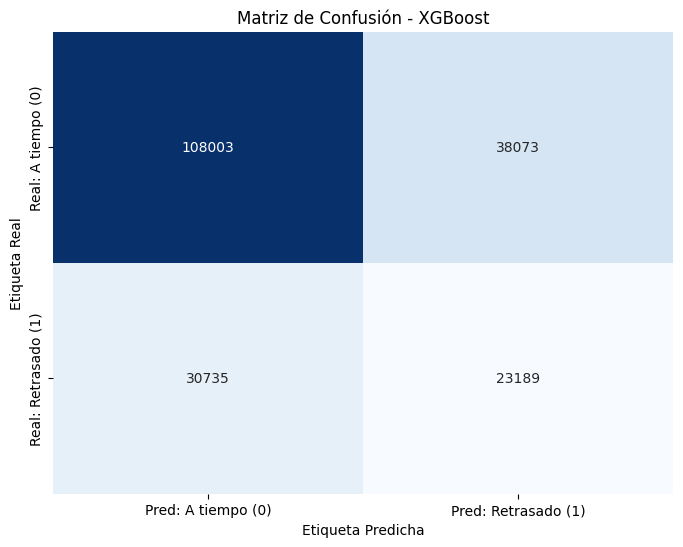

Detectaste correctamente 23189 retrasos (True Positives).
Te perdiste 30735 retrasos (False Negatives) - ¡Estos son los costosos!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, average_precision_score

# 1. Generar Predicciones
# XGBoost requiere que X_test esté en formato DMatrix
dtest = xgb.DMatrix(X_test)
y_pred_probs = bst.predict(dtest) # Devuelve probabilidades (0.0 a 1.0)

# Convertir a clases binarias (0 o 1) usando un umbral (por defecto 0.5)
y_pred_classes = (y_pred_probs > 0.5).astype(int)

# --- A. MATRIZ DE CONFUSIÓN (PLOT) ---
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_classes)

# Crear mapa de calor
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred: A tiempo (0)', 'Pred: Retrasado (1)'],
            yticklabels=['Real: A tiempo (0)', 'Real: Retrasado (1)'])

plt.title('Matriz de Confusión - XGBoost')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.show()

# Interpretación rápida impresa
tn, fp, fn, tp = cm.ravel()
print(f"Detectaste correctamente {tp} retrasos (True Positives).")
print(f"Te perdiste {fn} retrasos (False Negatives) - ¡Estos son los costosos!")


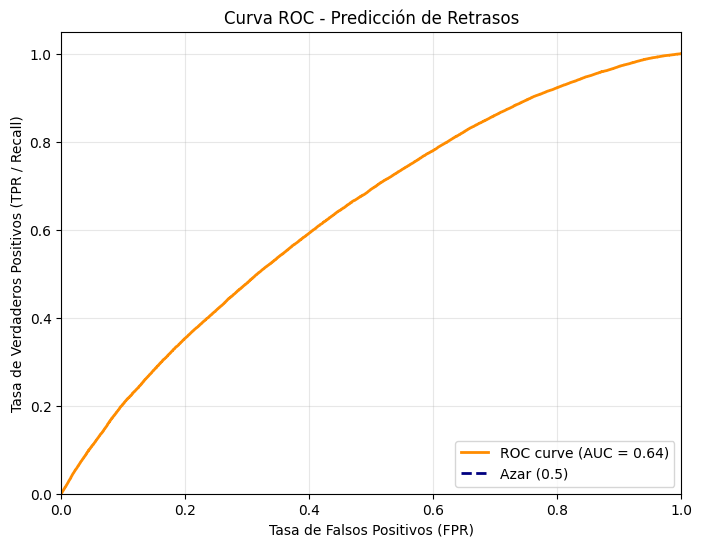

In [ ]:

# --- B. CURVA ROC (PLOT) ---
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([1], color='navy', lw=2, linestyle='--', label='Azar (0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
plt.title('Curva ROC - Predicción de Retrasos')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:

# --- C. REPORTE MÉTRICO EXTRA ---
# Dado el desbalance, calculamos también el PR-AUC (Average Precision)
pr_auc = average_precision_score(y_test, y_pred_probs)
print(f"\nROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC (Precisión-Recall): {pr_auc:.4f} <--- ¡Mira este valor por el desbalance!")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_classes))


ROC-AUC: 0.6375
PR-AUC (Precisión-Recall): 0.3728 <--- ¡Mira este valor por el desbalance!

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.78      0.74      0.76    146076
           1       0.38      0.43      0.40     53924

    accuracy                           0.66    200000
   macro avg       0.58      0.58      0.58    200000
weighted avg       0.67      0.66      0.66    200000



OTRO INTENTO

In [ ]:
# LightGBM training script (sparse X, gran escala, clases desbalanceadas)
import os
import lightgbm as lgb
import numpy as np
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

y_train = np.asarray(y_train).ravel()
y_val   = np.asarray(y_val).ravel()
y_test  = np.asarray(y_test).ravel()


Clase 0 (A tiempo): 5267131
Clase 1 (Retrasado): 1298135
Scale_pos_weight calculado: 4.06

Iniciando entrenamiento LightGBM...
Training until validation scores don't improve for 50 rounds
[50]	train's auc: 0.701893	valid's auc: 0.639245
[100]	train's auc: 0.708355	valid's auc: 0.646237
[150]	train's auc: 0.711975	valid's auc: 0.650947
[200]	train's auc: 0.713999	valid's auc: 0.652614
[250]	train's auc: 0.715477	valid's auc: 0.653769
[300]	train's auc: 0.716661	valid's auc: 0.654045
[350]	train's auc: 0.717661	valid's auc: 0.654604
[400]	train's auc: 0.718567	valid's auc: 0.655033
[450]	train's auc: 0.719265	valid's auc: 0.655576
[500]	train's auc: 0.720026	valid's auc: 0.655928
[550]	train's auc: 0.72074	valid's auc: 0.655552
Early stopping, best iteration is:
[513]	train's auc: 0.720211	valid's auc: 0.655962


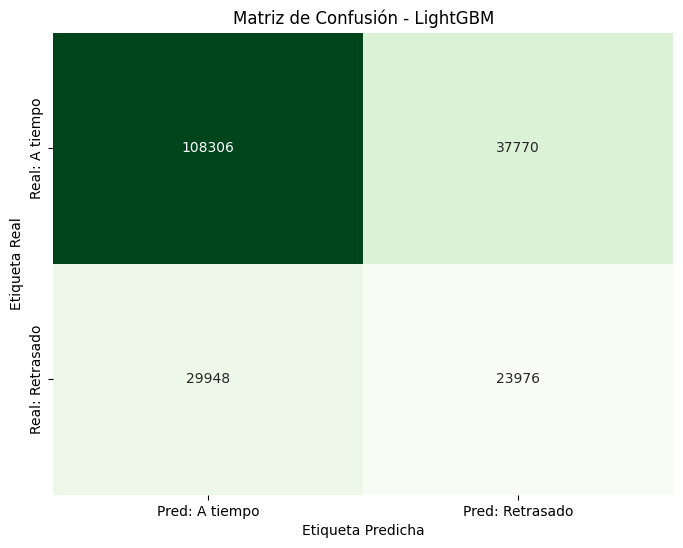

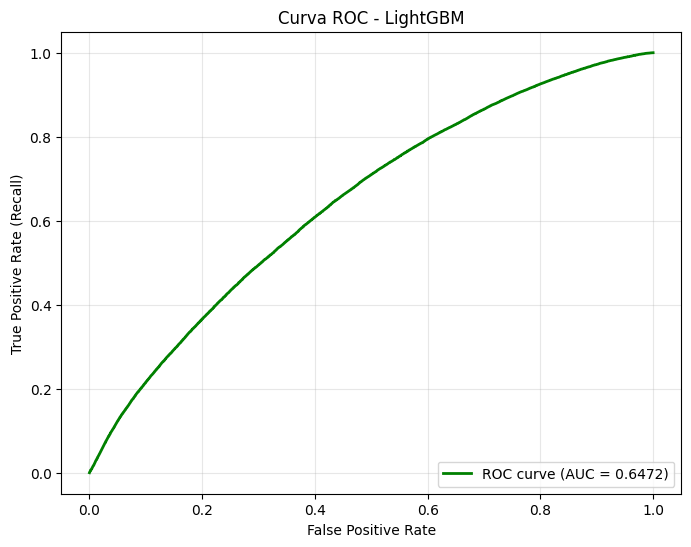


RESULTADOS DEL MODELO LIGHTGBM
ROC-AUC: 0.6472
PR-AUC (Precision-Recall): 0.3842  <-- Métrica clave por desbalance

Reporte de Clasificación:
              precision    recall  f1-score   support

    A tiempo       0.78      0.74      0.76    146076
   Retrasado       0.39      0.44      0.41     53924

    accuracy                           0.66    200000
   macro avg       0.59      0.59      0.59    200000
weighted avg       0.68      0.66      0.67    200000



In [ ]:
import lightgbm as lgb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, average_precision_score

# -------------------------------------------------------------------------
# 1. Configuración del Balanceo de Clases
# -------------------------------------------------------------------------
# LightGBM maneja el desbalance con el parámetro 'scale_pos_weight'.
# Fórmula: número de negativos / número de positivos
n_pos = (y_train == 1).sum()
n_neg = (y_train == 0).sum()
ratio_desbalance = n_neg / n_pos

print(f"Clase 0 (A tiempo): {n_neg}")
print(f"Clase 1 (Retrasado): {n_pos}")
print(f"Scale_pos_weight calculado: {ratio_desbalance:.2f}")

# -------------------------------------------------------------------------
# 2. Creación de Datasets de LightGBM
# -------------------------------------------------------------------------
# LightGBM tiene su propia estructura de datos optimizada que consume muy poca RAM
# y acepta matrices dispersas (scipy.sparse) directamente.
train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

# -------------------------------------------------------------------------
# 3. Definición de Hiperparámetros
# -------------------------------------------------------------------------
params = {
    'objective': 'binary',            # Clasificación binaria
    'metric': 'auc',                  # Métrica para evaluar en validación
    'boosting_type': 'gbdt',          # Gradient Boosting Decision Tree estándar
    'scale_pos_weight': ratio_desbalance, # ¡CRÍTICO! Para el desbalance 80/20
    'learning_rate': 0.05,            # Velocidad de aprendizaje (eta)
    'num_leaves': 64,                 # LightGBM crece por hojas. >31 es más complejo
    'max_depth': -1,                  # -1 deja que el árbol crezca (controlado por num_leaves)
    'feature_fraction': 0.8,          # Subsample de columnas (evita overfitting)
    'bagging_fraction': 0.8,          # Subsample de filas
    'bagging_freq': 5,                # Frecuencia de bagging
    'verbose': -1,                    # Silenciar warnings no críticos
    'n_jobs': -1                      # Usar todos los núcleos del CPU
}

# -------------------------------------------------------------------------
# 4. Entrenamiento con Early Stopping
# -------------------------------------------------------------------------
print("\nIniciando entrenamiento LightGBM...")

# Callback para detener si no mejora en 50 rondas
callbacks = [lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=50)]

bst_lgb = lgb.train(
    params,
    train_data,
    num_boost_round=2000,             # Máximo de iteraciones
    valid_sets=[train_data, val_data],
    valid_names=['train', 'valid'],
    callbacks=callbacks
)

# -------------------------------------------------------------------------
# 5. Generar Predicciones y Evaluar
# -------------------------------------------------------------------------
# LightGBM predice probabilidades directamente (no log-odds)
y_pred_probs = bst_lgb.predict(X_test, num_iteration=bst_lgb.best_iteration)
y_pred_classes = (y_pred_probs > 0.5).astype(int)

# --- A. Matriz de Confusión ---
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Pred: A tiempo', 'Pred: Retrasado'],
            yticklabels=['Real: A tiempo', 'Real: Retrasado'])
plt.title('Matriz de Confusión - LightGBM')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.show()

# --- B. Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='green', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Curva ROC - LightGBM')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# --- C. Métricas Detalladas (Prioridad en Recall y PR-AUC) ---
pr_auc = average_precision_score(y_test, y_pred_probs)

print("\n" + "="*40)
print(f"RESULTADOS DEL MODELO LIGHTGBM")
print("="*40)
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC (Precision-Recall): {pr_auc:.4f}  <-- Métrica clave por desbalance")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_classes, target_names=['A tiempo', 'Retrasado']))




```
--- INTERPRETACIÓN DE ROC/AUC ---
ROC-AUC:  0.66
==================================================
REPORTE DE CLASIFICACIÓN MLP
==================================================
               precision    recall  f1-score   support

 A tiempo (0)       0.79      0.71      0.75    146076
Retrasado (1)       0.39      0.50      0.44     53924

     accuracy                           0.65    200000
    macro avg       0.59      0.61      0.59    200000
 weighted avg       0.69      0.65      0.67    200000


========================================
RESULTADOS DEL MODELO XGBOOST
========================================
ROC-AUC: 0.6375

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.78      0.74      0.76    146076
           1       0.38      0.43      0.40     53924

    accuracy                           0.66    200000
   macro avg       0.58      0.58      0.58    200000
weighted avg       0.67      0.66      0.66    200000


========================================
RESULTADOS DEL MODELO LIGHTGBM
========================================
ROC-AUC: 0.6472


Reporte de Clasificación:
              precision    recall  f1-score   support

    A tiempo       0.78      0.74      0.76    146076
   Retrasado       0.39      0.44      0.41     53924

    accuracy                           0.66    200000
   macro avg       0.59      0.59      0.59    200000
weighted avg       0.68      0.66      0.67    200000
```



In [ ]:

# --- Guardar modelo ---
model_path = os.path.join(base_path, 'lightgbm_model.txt')
bst.save_model(model_path)
print(f"Modelo guardado en: {model_path}")

# --- Predicciones (probabilidades) ---
y_val_pred_proba  = bst.predict(X_val, num_iteration=bst.best_iteration)
y_test_pred_proba = bst.predict(X_test, num_iteration=bst.best_iteration)

# --- Evaluación: ROC-AUC y PR-AUC (Average Precision) + threshold metrics ---
roc_auc_val = roc_auc_score(y_val, y_val_pred_proba)
pr_auc_val  = average_precision_score(y_val, y_val_pred_proba)

roc_auc_test = roc_auc_score(y_test, y_test_pred_proba)
pr_auc_test  = average_precision_score(y_test, y_test_pred_proba)

# Elegir un umbral operativo (ej. 0.5) o calibrar con validación
th = 0.5
y_test_pred = (y_test_pred_proba >= th).astype(int)

precision = precision_score(y_test, y_test_pred, zero_division=0)
recall    = recall_score(y_test, y_test_pred, zero_division=0)
f1        = f1_score(y_test, y_test_pred, zero_division=0)

print("=== Evaluación (Validation) ===")
print(f"ROC-AUC: {roc_auc_val:.4f} | PR-AUC (AP): {pr_auc_val:.4f}")
print("=== Evaluación (Test) ===")
print(f"ROC-AUC: {roc_auc_test:.4f} | PR-AUC (AP): {pr_auc_test:.4f}")
print(f"Threshold={th} -> Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

# --- (Opcional) Guardar predicciones para análisis posterior ---
np.save(os.path.join(base_path, 'y_val_pred_proba.npy'), y_val_pred_proba)
np.save(os.path.join(base_path, 'y_test_pred_proba.npy'), y_test_pred_proba)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras import regularizers
from tensorflow.keras.constraints import MaxNorm
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.metrics import AUC
import numpy as np
from sklearn.utils import class_weight

# --- Focal loss (opcional) ---
def focal_loss(gamma=2.0, alpha=0.25):
    def loss(y_true, y_pred):
        y_true = tf.reshape(tf.cast(y_true, tf.float32), (-1, 1))
        # clip for stability
        eps = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, eps, 1.0 - eps)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        bce = - (y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred))
        loss = alpha_t * tf.pow(1 - p_t, gamma) * bce
        return tf.reduce_mean(loss)
    return loss

# --- Parámetros recomendados ---
input_dim = X_train.shape[1]    # como tú lo defines
l2_coef = 1e-4                  # reducir respecto a 0.01
dropout_1 = 0.30
dropout_2 = 0.30
dropout_3 = 0.20
weight_decay = 1e-6             # para AdamW
clipnorm = 1.0
learning_rate = 1e-3

# --- Modelo (igual estructura pero con constraints más explícitos) ---
tf.keras.backend.clear_session()

model = Sequential()
model.add(Dense(
    64,
    input_dim=input_dim,
    activation='relu',
    kernel_regularizer=regularizers.l2(l2_coef),
    kernel_constraint=MaxNorm(3.0)    # limita magnitudes
))
model.add(BatchNormalization())
model.add(Dropout(dropout_1))

model.add(Dense(
    64,
    activation='relu',
    kernel_regularizer=regularizers.l2(l2_coef),
    kernel_constraint=MaxNorm(3.0)
))
model.add(BatchNormalization())
model.add(Dropout(dropout_2))

model.add(Dense(
    64,
    activation='relu',
    kernel_regularizer=regularizers.l2(l2_coef),
    kernel_constraint=MaxNorm(3.0)
))
model.add(BatchNormalization())
model.add(Dropout(dropout_3))

model.add(Dense(1, activation='sigmoid'))

# --- Optimizer: AdamW con clipnorm ---
# Nota: usar optimizador experimental si tu versión de TF lo soporta
try:
    optimizer = tf.keras.optimizers.experimental.AdamW(
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        clipnorm=clipnorm
    )
except Exception:
    optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate,
        clipnorm=clipnorm
    )

# --- Loss: binary_crossentropy o focal_loss() ---
use_focal = False  # cambia a True para probar focal loss
loss_fn = focal_loss(gamma=2.0, alpha=0.25) if use_focal else 'binary_crossentropy'

model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=[
        'accuracy',
        AUC(name='auc_pr', curve='PR')   # PR-AUC
    ]
)

model.summary()

# --- Callbacks: monitor por AUC-PR (mejor para desbalance) ---
callbacks = [
    EarlyStopping(monitor='val_auc_pr', mode='max', patience=8, restore_best_weights=True, verbose=1),
    ModelCheckpoint(
        filepath=os.path.join(base_path, 'best_model_aucpr.h5'),
        monitor='val_auc_pr',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(monitor='val_auc_pr', mode='max', factor=0.5, patience=4, min_lr=1e-6, verbose=1)
]

# --- Class weights (ya los calculaste, usar si no usas focal loss) ---
pesos_calculados = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(pesos_calculados))

# --- Entrenamiento ---
history = model.fit(
    X_train,   # asumes que tu pipeline acepta la sparse/matrix como X_train
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=2048,
    callbacks=callbacks,
    class_weight=class_weights_dict if not use_focal,  # si usas focal, no mezclar class_weight puede ser preferible
    verbose=1
)


SyntaxError: expected 'else' after 'if' expression (ipython-input-1412217535.py, line 127)

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.metrics import AUC
from sklearn.utils import class_weight



input_dim = X_train.shape[1]
learning_rate = 1e-3
l2_coef = 1e-4
batch_size = 512
epochs = 100


tf.keras.backend.clear_session()


model = Sequential([
    Dense(
        64,
        activation='relu',
        input_dim=input_dim,
        kernel_regularizer=regularizers.l2(l2_coef)
    ),
    BatchNormalization(),

    Dense(
        32,
        activation='relu',
        kernel_regularizer=regularizers.l2(l2_coef)
    ),
    BatchNormalization(),

    Dense(1, activation='sigmoid')
])


optimizer = tf.keras.optimizers.Adam(
    learning_rate=learning_rate,
    clipnorm=1.0
)



model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=[
        AUC(name='auc_pr', curve='PR'), 'accuracy'
    ]
)

model.summary()


pesos = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(pesos))

print("Class weights:", class_weights)


callbacks = [
    EarlyStopping(
        monitor='val_auc_pr',
        mode='max',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=os.path.join(base_path, 'best_model_pr_auc.h5'),
        monitor='val_auc_pr',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_auc_pr',
        mode='max',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]


history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,833 (34.50 KB)

 Trainable params: 8,641 (33.75 KB)

...

Class weights: {0: np.float64(0.6232298000562355), 1: np.float64(2.5287300627438594)}
Epoch 1/100
12821/12823 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6400 - auc_pr: 0.3536 - loss: 0.6445
Epoch 1: val_auc_pr improved from -inf to 0.27827, saving model to /content/drive/My Drive/Proyecto_Vuelos_Delay/best_model_pr_auc.h5


12823/12823 ━━━━━━━━━━━━━━━━━━━━ 217s 16ms/step - accuracy: 0.6401 - auc_pr: 0.3536 - loss: 0.6445 - val_accuracy: 0.6625 - val_auc_pr: 0.2783 - val_loss: 0.6080 - learning_rate: 0.0010
Epoch 2/100
12813/12823 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6531 - auc_pr: 0.3796 - loss: 0.6277
Epoch 2: val_auc_pr improved from 0.27827 to 0.28531, saving model to /content/drive/My Drive/Proyecto_Vuelos_Delay/best_model_pr_auc.h5


12823/12823 ━━━━━━━━━━━━━━━━━━━━ 254s 16ms/step - accuracy: 0.6531 - auc_pr: 0.3796 - loss: 0.6277 - val_accuracy: 0.6167 - val_auc_pr: 0.2853 - val_loss: 0.6396 - learning_rate: 0.0010
Epoch 3/100
12820/12823 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6561 - auc_pr: 0.3822 - loss: 0.6261
Epoch 3: val_auc_pr did not improve from 0.28531
12823/12823 ━━━━━━━━━━━━━━━━━━━━ 202s 16ms/step - accuracy: 0.6561 - auc_pr: 0.3822 - loss: 0.6261 - val_accuracy: 0.6404 - val_auc_pr: 0.2832 - val_loss: 0.6308 - learning_rate: 0.0010
Epoch 4/100
12818/12823 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6563 - auc_pr: 0.3827 - loss: 0.6257
Epoch 4: val_auc_pr did not improve from 0.28531
12823/12823 ━━━━━━━━━━━━━━━━━━━━ 205s 16ms/step - accuracy: 0.6563 - auc_pr: 0.3827 - loss: 0.6257 - val_accuracy: 0.5907 - val_auc_pr: 0.2851 - val_loss: 0.6638 - learning_rate: 0.0010
Epoch 5/100
12818/12823 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6569 - auc_pr: 0.3830 - loss: 0.6253
Epoch 5: val_auc_

12823/12823 ━━━━━━━━━━━━━━━━━━━━ 260s 16ms/step - accuracy: 0.6573 - auc_pr: 0.3835 - loss: 0.6246 - val_accuracy: 0.6449 - val_auc_pr: 0.2858 - val_loss: 0.6266 - learning_rate: 0.0010
Epoch 8/100
12812/12823 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6583 - auc_pr: 0.3841 - loss: 0.6245
Epoch 8: val_auc_pr did not improve from 0.28582
12823/12823 ━━━━━━━━━━━━━━━━━━━━ 200s 16ms/step - accuracy: 0.6583 - auc_pr: 0.3841 - loss: 0.6245 - val_accuracy: 0.6665 - val_auc_pr: 0.2845 - val_loss: 0.6180 - learning_rate: 0.0010
Epoch 9/100
12823/12823 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6577 - auc_pr: 0.3843 - loss: 0.6247
Epoch 9: val_auc_pr did not improve from 0.28582
12823/12823 ━━━━━━━━━━━━━━━━━━━━ 203s 16ms/step - accuracy: 0.6577 - auc_pr: 0.3843 - loss: 0.6247 - val_accuracy: 0.6477 - val_auc_pr: 0.2853 - val_loss: 0.6199 - learning_rate: 0.0010
Epoch 10/100
12818/12823 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6574 - auc_pr: 0.3846 - loss: 0.6246
Epoch 10: val_au

12823/12823 ━━━━━━━━━━━━━━━━━━━━ 202s 16ms/step - accuracy: 0.6579 - auc_pr: 0.3847 - loss: 0.6244 - val_accuracy: 0.6392 - val_auc_pr: 0.2897 - val_loss: 0.6321 - learning_rate: 0.0010
Epoch 13/100
12817/12823 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6578 - auc_pr: 0.3846 - loss: 0.6246
Epoch 13: val_auc_pr did not improve from 0.28965
12823/12823 ━━━━━━━━━━━━━━━━━━━━ 201s 16ms/step - accuracy: 0.6578 - auc_pr: 0.3846 - loss: 0.6246 - val_accuracy: 0.6082 - val_auc_pr: 0.2812 - val_loss: 0.6517 - learning_rate: 0.0010
Epoch 14/100
12821/12823 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6581 - auc_pr: 0.3858 - loss: 0.6240
Epoch 14: val_auc_pr did not improve from 0.28965
12823/12823 ━━━━━━━━━━━━━━━━━━━━ 200s 16ms/step - accuracy: 0.6581 - auc_pr: 0.3858 - loss: 0.6240 - val_accuracy: 0.5985 - val_auc_pr: 0.2853 - val_loss: 0.6577 - learning_rate: 0.0010
Epoch 15/100
12812/12823 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6572 - auc_pr: 0.3852 - loss: 0.6244
Epoch 15: va

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

y_pred_probs = model.predict(X_test)

y_pred_classes = (y_pred_probs > 0.5).astype(int)

print("Predicciones generadas con éxito.")

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
Predicciones generadas con éxito.


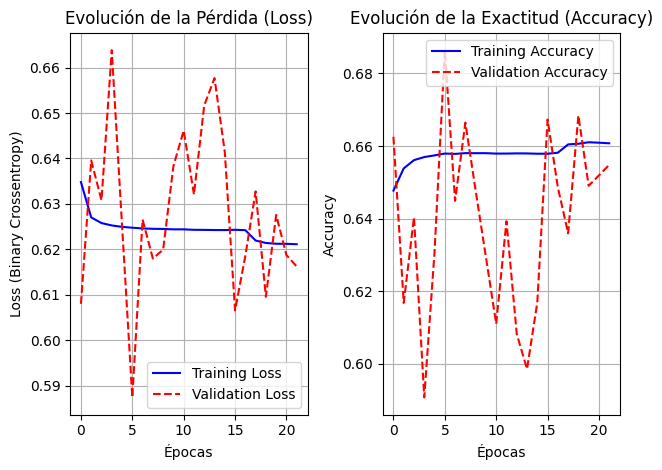

In [ ]:

# --- Gráfica 1: Loss vs Val_Loss ---
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red', linestyle='--')
plt.title('Evolución de la Pérdida (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Loss (Binary Crossentropy)')
plt.legend()
plt.grid(True)

# --- Gráfica 2: Accuracy vs Val_Accuracy ---
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', linestyle='--')
plt.title('Evolución de la Exactitud (Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()



REPORTE DE CLASIFICACIÓN (MÉTRICAS NUMÉRICAS)
               precision    recall  f1-score   support

 A tiempo (0)       0.79      0.70      0.74    146076
Retrasado (1)       0.38      0.49      0.42     53924

     accuracy                           0.64    200000
    macro avg       0.58      0.59      0.58    200000
 weighted avg       0.68      0.64      0.66    200000



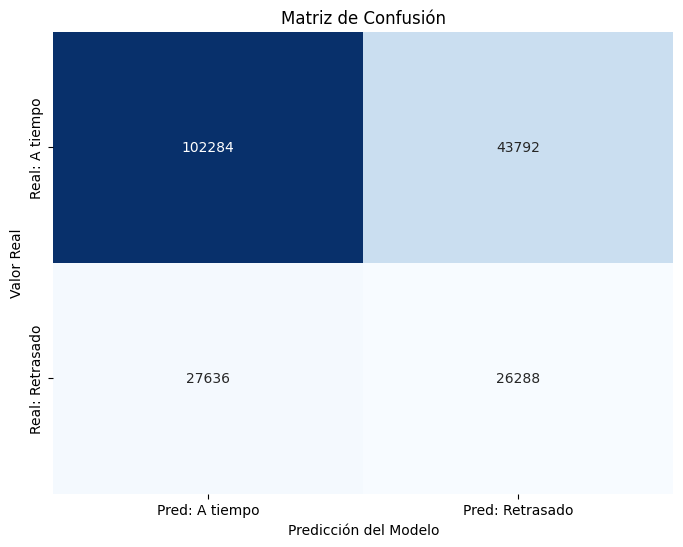


--- INTERPRETACIÓN DE LA MATRIZ ---
Vuelos A TIEMPO predichos correctamente (TN): 102284
Vuelos RETRASADOS predichos correctamente (TP): 26288 (¡Este es tu éxito detectando problemas!)
Falsas Alarmas (FP): 43792 (Predijiste retraso, pero llegó bien)
Retrasos NO detectados (FN): 27636 (El error más costoso: predijiste a tiempo, pero se retrasó)


In [ ]:
# Calcular la matriz
cm = confusion_matrix(y_test, y_pred_classes)

# --- Formato Print (Reporte de Clasificación) ---
print("\n" + "="*50)
print("REPORTE DE CLASIFICACIÓN (MÉTRICAS NUMÉRICAS)")
print("="*50)
print(classification_report(y_test, y_pred_classes, target_names=['A tiempo (0)', 'Retrasado (1)']))

# --- Formato Plot (Mapa de Calor) ---
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred: A tiempo', 'Pred: Retrasado'],
            yticklabels=['Real: A tiempo', 'Real: Retrasado'])
plt.title('Matriz de Confusión')
plt.ylabel('Valor Real')
plt.xlabel('Predicción del Modelo')
plt.show()

# Interpretación impresa específica para tu problema
tn, fp, fn, tp = cm.ravel()
print(f"\n--- INTERPRETACIÓN DE LA MATRIZ ---")
print(f"Vuelos A TIEMPO predichos correctamente (TN): {tn}")
print(f"Vuelos RETRASADOS predichos correctamente (TP): {tp} (¡Este es tu éxito detectando problemas!)")
print(f"Falsas Alarmas (FP): {fp} (Predijiste retraso, pero llegó bien)")
print(f"Retrasos NO detectados (FN): {fn} (El error más costoso: predijiste a tiempo, pero se retrasó)")


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import AUC


input_dim = X_train.shape[1]
learning_rate = 5e-4
batch_size = 4096
epochs = 50


tf.keras.backend.clear_session()
model = Sequential([
    Dense(
        64,
        activation='relu',
        input_dim=input_dim
    ),
    Dense(
        32,
        activation='relu'
    ),
    Dense(1, activation='sigmoid')
])

optimizer = tf.keras.optimizers.Adam(
    learning_rate=learning_rate
)


model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=[
        AUC(name='auc_pr', curve='PR'),'accuracy'
    ]
)

model.summary()


callbacks = [
    EarlyStopping(
        monitor='val_auc_pr',
        mode='max',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_auc_pr',
        mode='max',
        factor=0.5,
        patience=3,
        min_lr=1e-5,
        verbose=1
    )
]


history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=callbacks,
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,449 (33.00 KB)

 Trainable params: 8,449 (33.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1603/1603 ━━━━━━━━━━━━━━━━━━━━ 42s 24ms/step - auc_pr: 0.2798 - loss: 0.4935 - val_auc_pr: 0.2700 - val_loss: 0.4611 - learning_rate: 5.0000e-04
Epoch 2/50
1603/1603 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - auc_pr: 0.3681 - loss: 0.4556 - val_auc_pr: 0.2782 - val_loss: 0.4587 - learning_rate: 5.0000e-04
Epoch 3/50
1603/1603 ━━━━━━━━━━━━━━━━━━━━ 39s 24ms/step - auc_pr: 0.3762 - loss: 0.4538 - val_auc_pr: 0.2841 - val_loss: 0.4575 - learning_rate: 5.0000e-04
Epoch 4/50
1603/1603 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step - auc_pr: 0.3810 - loss: 0.4520 - val_auc_pr: 0.2836 - val_loss: 0.4574 - learning_rate: 5.0000e-04
Epoch 5/50
1603/1603 ━━━━━━━━━━━━━━━━━━━━ 40s 24ms/step - auc_pr: 0.3824 - loss: 0.4516 - val_auc_pr: 0.2816 - val_loss: 0.4577 - learning_rate: 5.0000e-04
Epoch 6/50
1602/1603 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - auc_pr: 0.3850 - loss: 0.4503
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
1603/1603 ━━━━━━━━━━━━━━━━━━━━ 40s 24ms/step - auc_pr: 0.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

y_pred_probs = model.predict(X_test)

y_pred_classes = (y_pred_probs > 0.5).astype(int)

print("Predicciones generadas con éxito.")

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step
Predicciones generadas con éxito.


KeyError: 'accuracy'

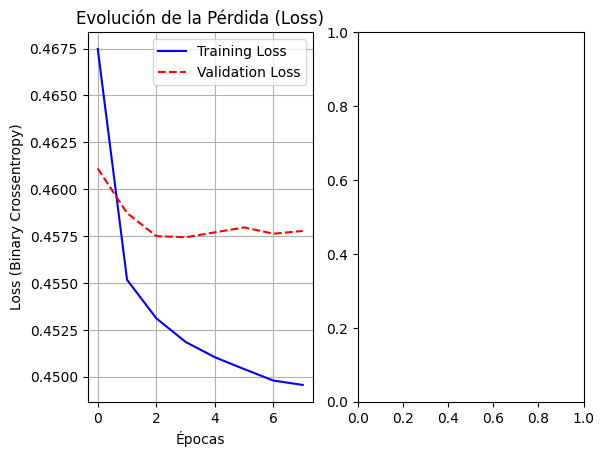

In [ ]:

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red', linestyle='--')
plt.title('Evolución de la Pérdida (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Loss (Binary Crossentropy)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', linestyle='--')
plt.title('Evolución de la Exactitud (Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
from sklearn.metrics import precision_recall_curve, classification_report

# Probabilidades del modelo
y_proba = model.predict(X_test, batch_size=8192).ravel()

# Curva Precision-Recall
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# F1 por umbral
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Mejor umbral según F1: {best_threshold:.3f}")
print(f"Precision (1): {precision[best_idx]:.3f}")
print(f"Recall (1): {recall[best_idx]:.3f}")
print(f"F1 (1): {f1_scores[best_idx]:.3f}")


25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step
Mejor umbral según F1: 0.165
Precision (1): 0.342
Recall (1): 0.730
F1 (1): 0.466


In [ ]:
y_pred_opt = (y_proba >= best_threshold).astype(int)

print(classification_report(
    y_test,
    y_pred_opt,
    target_names=["A tiempo (0)", "Retrasado (1)"]
))


               precision    recall  f1-score   support

 A tiempo (0)       0.83      0.48      0.61    146076
Retrasado (1)       0.34      0.73      0.47     53924

     accuracy                           0.55    200000
    macro avg       0.59      0.61      0.54    200000
 weighted avg       0.70      0.55      0.57    200000




REPORTE DE CLASIFICACIÓN (MÉTRICAS NUMÉRICAS)
               precision    recall  f1-score   support

 A tiempo (0)       0.79      0.70      0.74    146076
Retrasado (1)       0.38      0.49      0.42     53924

     accuracy                           0.64    200000
    macro avg       0.58      0.59      0.58    200000
 weighted avg       0.68      0.64      0.66    200000



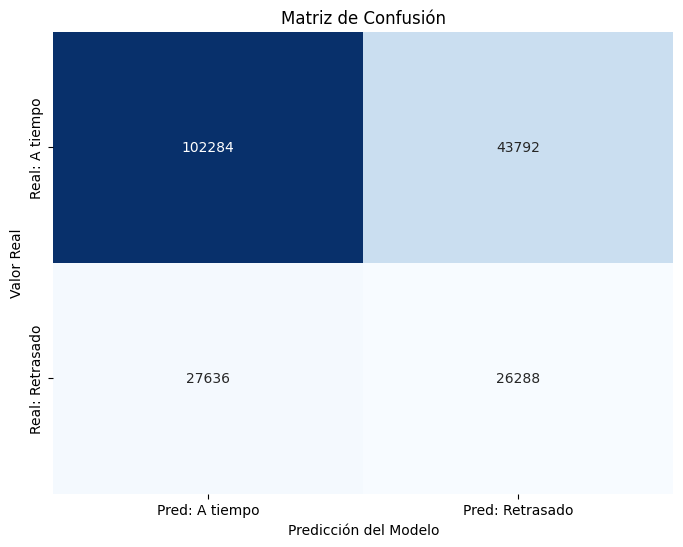


--- INTERPRETACIÓN DE LA MATRIZ ---
Vuelos A TIEMPO predichos correctamente (TN): 102284
Vuelos RETRASADOS predichos correctamente (TP): 26288 (¡Este es tu éxito detectando problemas!)
Falsas Alarmas (FP): 43792 (Predijiste retraso, pero llegó bien)
Retrasos NO detectados (FN): 27636 (El error más costoso: predijiste a tiempo, pero se retrasó)


In [ ]:
# Calcular la matriz
cm = confusion_matrix(y_test, y_pred_classes)

# --- Formato Print (Reporte de Clasificación) ---
print("\n" + "="*50)
print("REPORTE DE CLASIFICACIÓN (MÉTRICAS NUMÉRICAS)")
print("="*50)
print(classification_report(y_test, y_pred_classes, target_names=['A tiempo (0)', 'Retrasado (1)']))

# --- Formato Plot (Mapa de Calor) ---
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred: A tiempo', 'Pred: Retrasado'],
            yticklabels=['Real: A tiempo', 'Real: Retrasado'])
plt.title('Matriz de Confusión')
plt.ylabel('Valor Real')
plt.xlabel('Predicción del Modelo')
plt.show()

# Interpretación impresa específica para tu problema
tn, fp, fn, tp = cm.ravel()
print(f"\n--- INTERPRETACIÓN DE LA MATRIZ ---")
print(f"Vuelos A TIEMPO predichos correctamente (TN): {tn}")
print(f"Vuelos RETRASADOS predichos correctamente (TP): {tp} (¡Este es tu éxito detectando problemas!)")
print(f"Falsas Alarmas (FP): {fp} (Predijiste retraso, pero llegó bien)")
print(f"Retrasos NO detectados (FN): {fn} (El error más costoso: predijiste a tiempo, pero se retrasó)")


In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_probs)


In [ ]:
import numpy as np

recall_target = 0.70
idx = np.where(recall >= recall_target)[0][-1]

threshold = thresholds[idx]
print(f"Umbral seleccionado: {threshold:.3f}")
print(f"Precision: {precision[idx]:.3f}")
print(f"Recall: {recall[idx]:.3f}")


Umbral seleccionado: 0.425
Precision: 0.338
Recall: 0.700


In [ ]:
f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1)
threshold = thresholds[best_idx]


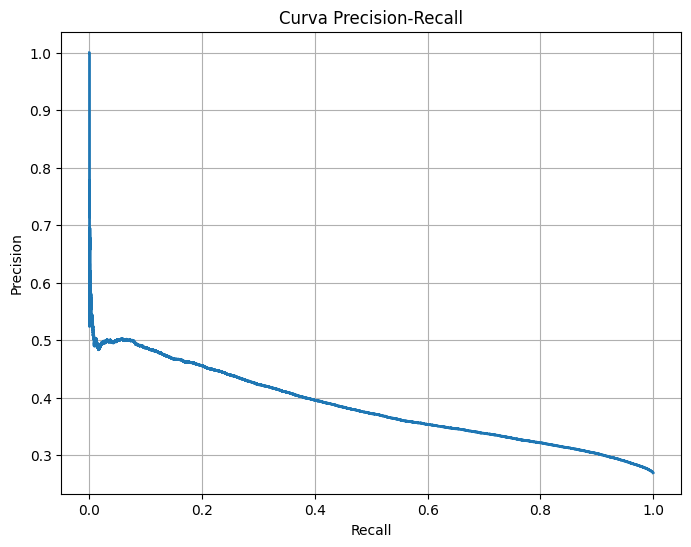

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_test, y_pred_probs)

print(f"PR-AUC (Average Precision): {pr_auc:.4f}")


PR-AUC (Average Precision): 0.3844


In [ ]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(
    y_test, y_pred_probs
)


In [ ]:
recall_target = 0.70

idx = np.where(recall[:-1] >= recall_target)[0][-1]
threshold = thresholds[idx]

print(f"Umbral seleccionado: {threshold:.4f}")
print(f"Precision: {precision[idx]:.3f}")
print(f"Recall: {recall[idx]:.3f}")


Umbral seleccionado: 0.4251
Precision: 0.338
Recall: 0.700


In [ ]:
f1 = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-8)
best_idx = np.argmax(f1)

threshold = thresholds[best_idx]

print(f"Umbral óptimo (F1): {threshold:.4f}")
print(f"Precision: {precision[best_idx]:.3f}")
print(f"Recall: {recall[best_idx]:.3f}")
print(f"F1: {f1[best_idx]:.3f}")


Umbral óptimo (F1): 0.3791
Precision: 0.321
Recall: 0.804
F1: 0.459


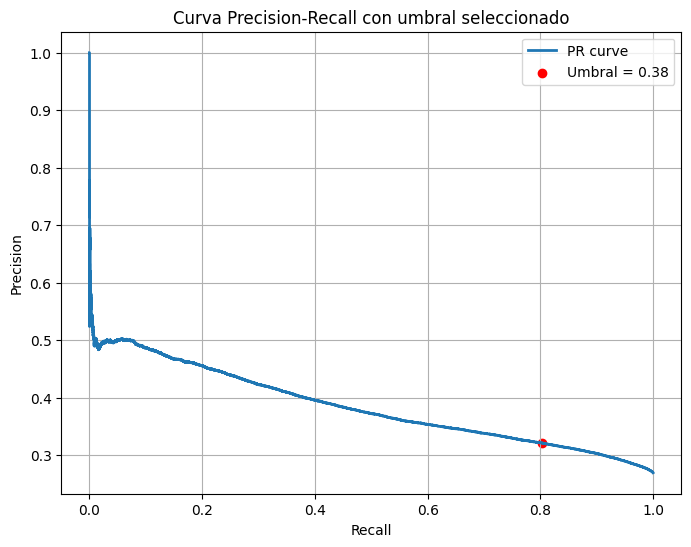

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, lw=2, label="PR curve")
plt.scatter(
    recall[best_idx],
    precision[best_idx],
    color='red',
    label=f"Umbral = {threshold:.2f}"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall con umbral seleccionado")
plt.legend()
plt.grid(True)
plt.show()


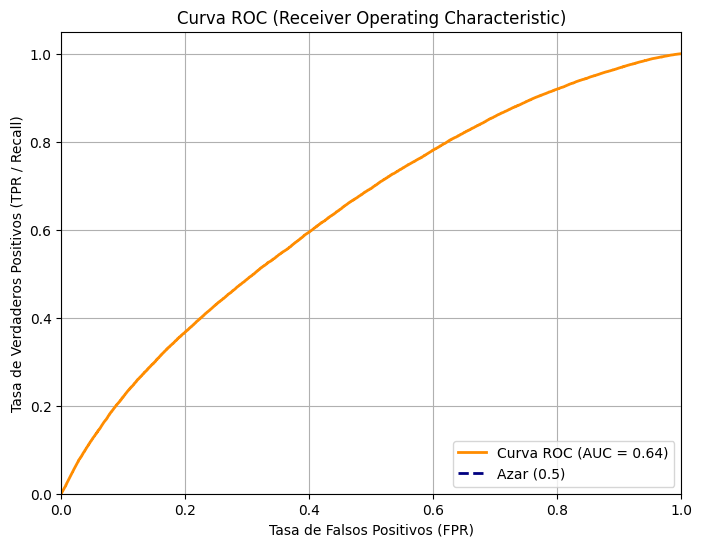


--- INTERPRETACIÓN DE ROC/AUC ---
El Área Bajo la Curva (AUC) es: 0.64
>> REGULAR: El modelo es mejor que el azar, pero necesita mejoras.


In [ ]:
# Calcular curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([7], color='navy', lw=2, linestyle='--', label='Azar (0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
plt.title('Curva ROC (Receiver Operating Characteristic)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Interpretación en texto
print("\n--- INTERPRETACIÓN DE ROC/AUC ---")
print(f"El Área Bajo la Curva (AUC) es: {roc_auc:.2f}")
if roc_auc > 0.8:
    print(">> EXCELENTE: El modelo distingue muy bien entre vuelos retrasados y a tiempo.")
elif roc_auc > 0.7:
    print(">> BUENO: El modelo tiene una capacidad aceptable de discriminación.")
elif roc_auc > 0.5:
    print(">> REGULAR: El modelo es mejor que el azar, pero necesita mejoras.")
else:
    print(">> MALO: El modelo no está aprendiendo nada útil (o está invirtiendo las clases).")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,833 (34.50 KB)

 Trainable params: 8,641 (33.75 KB)

...

1603/1603 ━━━━━━━━━━━━━━━━━━━━ 78s 27ms/step - accuracy: 0.8072 - auc_roc: 0.7181 - loss: 0.4489 - val_accuracy: 0.8150 - val_auc_roc: 0.6468 - val_loss: 0.4601 - learning_rate: 2.5000e-04
Epoch 15/50
1599/1603 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8071 - auc_roc: 0.7182 - loss: 0.4491
Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 15: val_auc_roc did not improve from 0.64675
1603/1603 ━━━━━━━━━━━━━━━━━━━━ 82s 28ms/step - accuracy: 0.8071 - auc_roc: 0.7182 - loss: 0.4491 - val_accuracy: 0.8149 - val_auc_roc: 0.6461 - val_loss: 0.4601 - learning_rate: 2.5000e-04
Epoch 16/50
1600/1603 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8072 - auc_roc: 0.7191 - loss: 0.4485
Epoch 16: val_auc_roc did not improve from 0.64675
1603/1603 ━━━━━━━━━━━━━━━━━━━━ 82s 27ms/step - accuracy: 0.8072 - auc_roc: 0.7191 - loss: 0.4485 - val_accuracy: 0.8149 - val_auc_roc: 0.6462 - val_loss: 0.4603 - learning_rate: 1.2500e-04
Epoch 17/50
1599/1603 ━━━━━━━━━━━━━━━

1603/1603 ━━━━━━━━━━━━━━━━━━━━ 46s 28ms/step - accuracy: 0.8072 - auc_roc: 0.7192 - loss: 0.4485 - val_accuracy: 0.8148 - val_auc_roc: 0.6482 - val_loss: 0.4598 - learning_rate: 1.2500e-04
Epoch 19/50
1602/1603 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8074 - auc_roc: 0.7195 - loss: 0.4480
Epoch 19: val_auc_roc improved from 0.64822 to 0.64826, saving model to /content/drive/My Drive/Proyecto_Vuelos_Delay/mlp_best_aucroc.h5


1603/1603 ━━━━━━━━━━━━━━━━━━━━ 45s 28ms/step - accuracy: 0.8074 - auc_roc: 0.7195 - loss: 0.4480 - val_accuracy: 0.8149 - val_auc_roc: 0.6483 - val_loss: 0.4595 - learning_rate: 1.2500e-04
Epoch 20/50
1601/1603 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8072 - auc_roc: 0.7194 - loss: 0.4483
Epoch 20: val_auc_roc did not improve from 0.64826
1603/1603 ━━━━━━━━━━━━━━━━━━━━ 83s 28ms/step - accuracy: 0.8072 - auc_roc: 0.7194 - loss: 0.4483 - val_accuracy: 0.8150 - val_auc_roc: 0.6456 - val_loss: 0.4602 - learning_rate: 1.2500e-04
Epoch 21/50
1599/1603 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8078 - auc_roc: 0.7198 - loss: 0.4474
Epoch 21: val_auc_roc did not improve from 0.64826
1603/1603 ━━━━━━━━━━━━━━━━━━━━ 47s 29ms/step - accuracy: 0.8078 - auc_roc: 0.7198 - loss: 0.4474 - val_accuracy: 0.8147 - val_auc_roc: 0.6476 - val_loss: 0.4598 - learning_rate: 1.2500e-04
Epoch 22/50
1602/1603 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8075 - auc_roc: 0.7200 - loss: 0.4478
Epoch 2

1603/1603 ━━━━━━━━━━━━━━━━━━━━ 82s 28ms/step - accuracy: 0.8073 - auc_roc: 0.7201 - loss: 0.4478 - val_accuracy: 0.8147 - val_auc_roc: 0.6486 - val_loss: 0.4595 - learning_rate: 6.2500e-05
Epoch 24/50
1602/1603 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8073 - auc_roc: 0.7200 - loss: 0.4479
Epoch 24: val_auc_roc improved from 0.64855 to 0.64858, saving model to /content/drive/My Drive/Proyecto_Vuelos_Delay/mlp_best_aucroc.h5


1603/1603 ━━━━━━━━━━━━━━━━━━━━ 48s 30ms/step - accuracy: 0.8073 - auc_roc: 0.7200 - loss: 0.4479 - val_accuracy: 0.8147 - val_auc_roc: 0.6486 - val_loss: 0.4593 - learning_rate: 6.2500e-05
Epoch 25/50
1599/1603 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8075 - auc_roc: 0.7204 - loss: 0.4476
Epoch 25: val_auc_roc did not improve from 0.64858
1603/1603 ━━━━━━━━━━━━━━━━━━━━ 45s 27ms/step - accuracy: 0.8075 - auc_roc: 0.7204 - loss: 0.4476 - val_accuracy: 0.8144 - val_auc_roc: 0.6471 - val_loss: 0.4602 - learning_rate: 6.2500e-05
Epoch 26/50
1600/1603 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8075 - auc_roc: 0.7203 - loss: 0.4476
Epoch 26: val_auc_roc did not improve from 0.64858
1603/1603 ━━━━━━━━━━━━━━━━━━━━ 83s 28ms/step - accuracy: 0.8075 - auc_roc: 0.7203 - loss: 0.4476 - val_accuracy: 0.8147 - val_auc_roc: 0.6466 - val_loss: 0.4599 - learning_rate: 6.2500e-05
Epoch 27/50
1601/1603 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8078 - auc_roc: 0.7206 - loss: 0.4471
Epoch 2

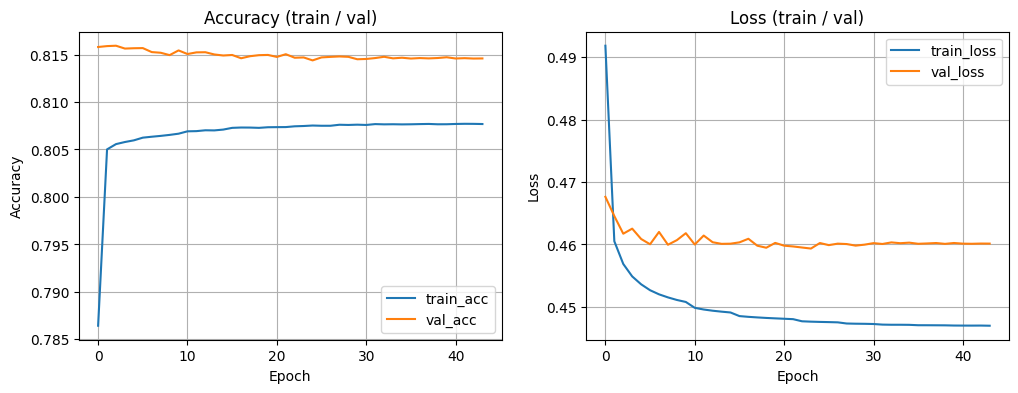

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step

--- METRICAS EN TEST (umbral 0.5) ---
Accuracy: 0.7303
Precision (positiva=1): 0.4896
Recall (positiva=1): 0.0065

Classification report:

               precision    recall  f1-score   support

 A tiempo (0)       0.73      1.00      0.84    146076
Retrasado (1)       0.49      0.01      0.01     53924

     accuracy                           0.73    200000
    macro avg       0.61      0.50      0.43    200000
 weighted avg       0.67      0.73      0.62    200000

Confusion matrix (rows: true, cols: pred):
 [[145708    368]
 [ 53571    353]]


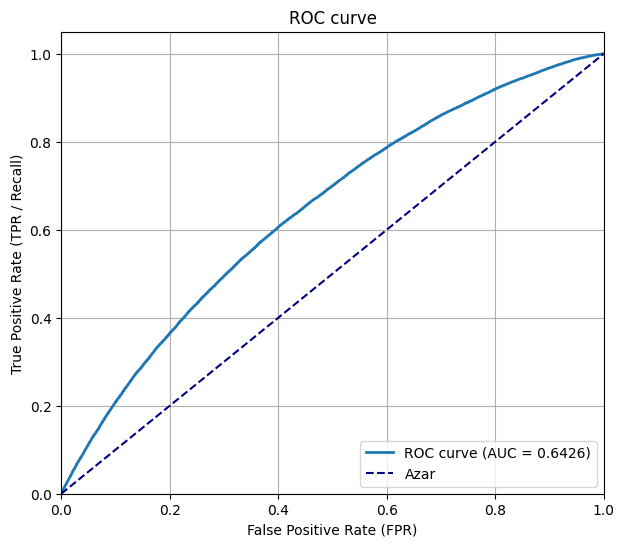

ROC AUC: 0.6426
PR-AUC (Average Precision): 0.3789


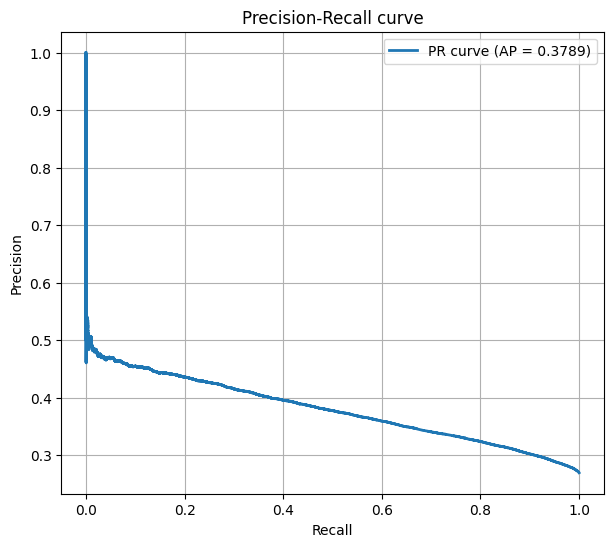


--- Umbral óptimo según F1 ---
Threshold (F1-opt): 0.1389
Precision @threshold: 0.3298
Recall @threshold: 0.7694
F1 @threshold: 0.4617

Reporte con umbral F1-opt:
               precision    recall  f1-score   support

 A tiempo (0)       0.83      0.42      0.56    146076
Retrasado (1)       0.33      0.77      0.46     53924

     accuracy                           0.52    200000
    macro avg       0.58      0.60      0.51    200000
 weighted avg       0.70      0.52      0.53    200000

Confusion matrix (F1-opt):
 [[61759 84317]
 [12437 41487]]


In [ ]:
# MLP escalable + evaluación: accuracy (train/val), precision, recall y curva ROC
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.metrics import AUC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score
)
from sklearn.utils import class_weight

# -------------------------
# 1) Hiperparámetros
# -------------------------
input_dim = X_train.shape[1]
learning_rate = 5e-4
l2_coef = 1e-4
batch_size = 4096     # ajustado a tu escala
epochs = 50

# -------------------------
# 2) Limpiar sesión
# -------------------------
tf.keras.backend.clear_session()

# -------------------------
# 3) Construcción del modelo
# -------------------------
model = Sequential([
    Dense(64, activation='relu', input_dim=input_dim,
          kernel_regularizer=regularizers.l2(l2_coef)),
    BatchNormalization(),
    Dense(32, activation='relu',
          kernel_regularizer=regularizers.l2(l2_coef)),
    BatchNormalization(),
    Dense(1, activation='sigmoid')
])

# -------------------------
# 4) Optimizador y compilación
# -------------------------
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=1.0)

# Usamos AUC (ROC) como métrica principal de discriminación en entrenamiento
model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy', AUC(name='auc_roc', curve='ROC')]
)

model.summary()

# -------------------------
# 5) Callbacks robustos
# -------------------------
callbacks = [
    EarlyStopping(monitor='val_auc_roc', mode='max', patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_auc_roc', mode='max', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint(filepath=os.path.join(base_path, 'mlp_best_aucroc.h5'),
                    monitor='val_auc_roc', mode='max', save_best_only=True, verbose=1)
]

# -------------------------
# 6) (Opcional) class weights
# -------------------------
# Con tu prevalencia (~20% positivos) class_weight no es obligatorio, pero puedes usarlo si quieres priorizar:
# pesos = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
# class_weights = dict(enumerate(pesos))
# En este script lo dejamos comentado; descomenta la línea class_weight=... si decides usarlo.

# -------------------------
# 7) Entrenamiento
# -------------------------
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=callbacks,
    verbose=1
    # , class_weight=class_weights   # descomentar si usas class weights
)

# -------------------------
# 8) Guardar historia y modelo
# -------------------------
model.save(os.path.join(base_path, 'mlp_final.h5'))

# -------------------------
# 9) Curvas de entrenamiento: accuracy y loss
# -------------------------
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy (train / val)')
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss (train / val)')
plt.legend()
plt.grid()
plt.show()

# -------------------------
# 10) Predicciones (probabilidades) en test
# -------------------------
# usa batch_size grande para eficiencia
y_test_proba = model.predict(X_test, batch_size=8192).ravel()

# umbral por defecto 0.5
y_test_pred_default = (y_test_proba >= 0.5).astype(int)

# -------------------------
# 11) Métricas con sklearn (test)
# -------------------------
acc_test = accuracy_score(y_test, y_test_pred_default)
prec_test = precision_score(y_test, y_test_pred_default, zero_division=0)
rec_test = recall_score(y_test, y_test_pred_default, zero_division=0)

print("\n--- METRICAS EN TEST (umbral 0.5) ---")
print(f"Accuracy: {acc_test:.4f}")
print(f"Precision (positiva=1): {prec_test:.4f}")
print(f"Recall (positiva=1): {rec_test:.4f}")
print("\nClassification report:\n")
print(classification_report(y_test, y_test_pred_default, target_names=['A tiempo (0)', 'Retrasado (1)']))

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred_default)
print("Confusion matrix (rows: true, cols: pred):\n", cm)

# -------------------------
# 12) Curva ROC y AUC
# -------------------------
fpr, tpr, roc_thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0,1],[0,1], linestyle='--', color='navy', label='Azar')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR / Recall)')
plt.title('ROC curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

print(f"ROC AUC: {roc_auc:.4f}")

# -------------------------
# 13) Curva Precision-Recall y PR-AUC (Average Precision)
# -------------------------
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_test_proba)
pr_auc = average_precision_score(y_test, y_test_proba)
print(f"PR-AUC (Average Precision): {pr_auc:.4f}")

plt.figure(figsize=(7,6))
plt.plot(recall, precision, lw=2, label=f'PR curve (AP = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve')
plt.grid()
plt.legend()
plt.show()

# -------------------------
# 14) Selección de umbral (ejemplo: maximizar F1)
# -------------------------
# Nota: pr_thresholds tiene len = len(precision)-1
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold_f1 = pr_thresholds[best_idx]
best_precision = precision[best_idx]
best_recall = recall[best_idx]
best_f1 = f1_scores[best_idx]

print("\n--- Umbral óptimo según F1 ---")
print(f"Threshold (F1-opt): {best_threshold_f1:.4f}")
print(f"Precision @threshold: {best_precision:.4f}")
print(f"Recall @threshold: {best_recall:.4f}")
print(f"F1 @threshold: {best_f1:.4f}")

# Evaluar con ese umbral
y_test_pred_opt = (y_test_proba >= best_threshold_f1).astype(int)
print("\nReporte con umbral F1-opt:")
print(classification_report(y_test, y_test_pred_opt, target_names=['A tiempo (0)', 'Retrasado (1)']))
print("Confusion matrix (F1-opt):\n", confusion_matrix(y_test, y_test_pred_opt))


In [ ]:
import numpy as np
from sklearn.utils import resample

# ==================================================
# UNDERSAMPLING CORRECTO DE LA CLASE MAYORITARIA
# ==================================================

# 1. Obtener índices por clase (NO separar X todavía)
idx_0 = np.where(y_train == 0)[0]
idx_1 = np.where(y_train == 1)[0]

print("Distribución original:")
print("Clase 0:", len(idx_0))
print("Clase 1:", len(idx_1))

# 2. Número objetivo (1:1)
n_samples = len(idx_1)

# 3. Submuestreo aleatorio de la clase mayoritaria
idx_0_down = resample(
    idx_0,
    replace=False,
    n_samples=n_samples,
    random_state=42
)

# 4. Unir índices
idx_balanced = np.concatenate([idx_0_down, idx_1])

# 5. Mezclar índices
perm = np.random.permutation(len(idx_balanced))
idx_balanced = idx_balanced[perm]

# 6. Construir datasets balanceados (indexación directa)
X_train = X_train[idx_balanced]
y_train = y_train[idx_balanced]

# 7. Verificación final
print("\nDistribución después de undersampling:")
print("Clase 0:", np.sum(y_train == 0))
print("Clase 1:", np.sum(y_train == 1))

print("Shape X_train_bal:", X_train.shape)


Distribución original:
Clase 0: 5267131
Clase 1: 1298135

Distribución después de undersampling:
Clase 0: 1298135
Clase 1: 1298135
Shape X_train_bal: (2596270, 98)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=1024,
    callbacks=[early_stop],
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 63s 21ms/step - accuracy: 0.6324 - loss: 0.6412 - val_accuracy: 0.6295 - val_loss: 0.6293
Epoch 2/50
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 42s 16ms/step - accuracy: 0.6458 - loss: 0.6304 - val_accuracy: 0.5821 - val_loss: 0.6461
Epoch 3/50
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 43s 17ms/step - accuracy: 0.6484 - loss: 0.6282 - val_accuracy: 0.6341 - val_loss: 0.6284
Epoch 4/50
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 40s 16ms/step - accuracy: 0.6496 - loss: 0.6272 - val_accuracy: 0.6297 - val_loss: 0.6387
Epoch 5/50
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - accuracy: 0.6503 - loss: 0.6264 - val_accuracy: 0.6235 - val_loss: 0.6403
Epoch 6/50
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 42s 16ms/step - accuracy: 0.6512 - loss: 0.6260 - val_accuracy: 0.6178 - val_loss: 0.6367
Epoch 7/50
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - accuracy: 0.6523 - loss: 0.6250 - val_accuracy: 0.5913 - val_loss: 0.6441
Epoch 8/50
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 40s 16ms/step - accuracy: 0.6526 -

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    roc_auc_score, roc_curve, classification_report
)
import matplotlib.pyplot as plt

# Probabilidades
y_val_probs = model.predict(X_val).ravel()

# Umbral estándar
threshold = 0.5
y_val_pred = (y_val_probs >= threshold).astype(int)

print("\n--- MÉTRICAS ---")
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred))
print("Recall:", recall_score(y_val, y_val_pred))
print("AUC:", roc_auc_score(y_val, y_val_probs))

print("\nReporte de clasificación:")
print(classification_report(y_val, y_val_pred))


6250/6250 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step

--- MÉTRICAS ---
Accuracy: 0.636455
Precision: 0.2690039655971571
Recall: 0.5673283188964618
AUC: 0.6513597667454778

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.87      0.65      0.75    163173
           1       0.27      0.57      0.36     36827

    accuracy                           0.64    200000
   macro avg       0.57      0.61      0.56    200000
weighted avg       0.76      0.64      0.68    200000



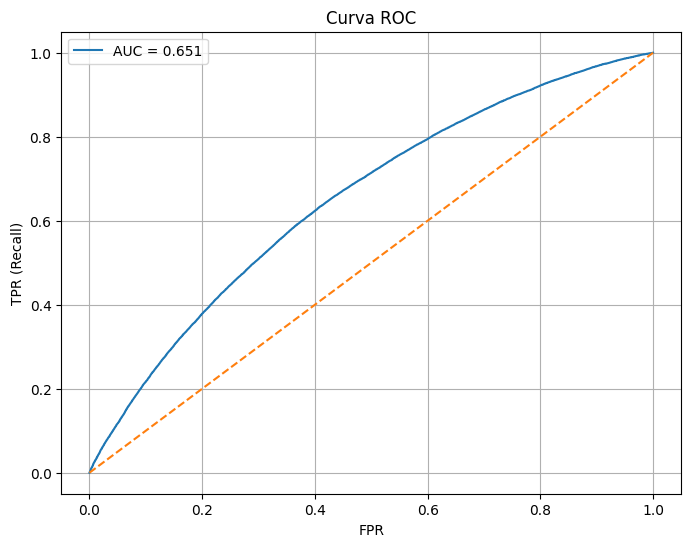

In [ ]:
fpr, tpr, thresholds = roc_curve(y_val, y_val_probs)
auc_score = roc_auc_score(y_val, y_val_probs)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], '--')
plt.xlabel("FPR")
plt.ylabel("TPR (Recall)")
plt.title("Curva ROC")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# Probabilidades del modelo
y_pred_probs = model.predict(X_val).ravel()


6250/6250 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step


In [ ]:
precision, recall, thresholds = precision_recall_curve(y_val, y_pred_probs)


In [ ]:
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-8)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Umbral óptimo (máx F1):", best_threshold)
print("Precision en umbral óptimo:", precision[best_idx])
print("Recall en umbral óptimo:", recall[best_idx])
print("F1 máximo:", f1_scores[best_idx])


Umbral óptimo (máx F1): 0.4771981
Precision en umbral óptimo: 0.2591305313419577
Recall en umbral óptimo: 0.6336655171477449
F1 máximo: 0.3678378294575892


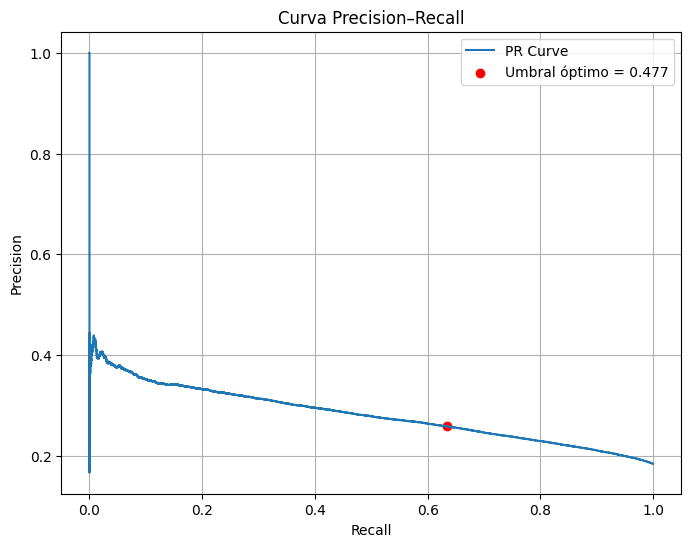

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label="PR Curve")
plt.scatter(
    recall[best_idx],
    precision[best_idx],
    color='red',
    label=f"Umbral óptimo = {best_threshold:.3f}"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision–Recall")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
y_pred_opt = (y_pred_probs >= best_threshold).astype(int)


In [ ]:
print("Reporte de clasificación (umbral óptimo):")
print(classification_report(y_val, y_pred_opt, digits=3))

print("Matriz de confusión:")
print(confusion_matrix(y_val, y_pred_opt))


Reporte de clasificación (umbral óptimo):
              precision    recall  f1-score   support

           0      0.877     0.591     0.706    163173
           1      0.259     0.634     0.368     36827

    accuracy                          0.599    200000
   macro avg      0.568     0.612     0.537    200000
weighted avg      0.763     0.599     0.644    200000

Matriz de confusión:
[[96454 66719]
 [13491 23336]]


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)
import matplotlib.pyplot as plt
import numpy as np
logreg = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",      # Convexo, estable, estándar
    max_iter=1000,
    n_jobs=-1
)


In [ ]:
logreg.fit(X_train, y_train)


LogisticRegression(max_iter=1000, n_jobs=-1)

In [ ]:
y_val_probs = logreg.predict_proba(X_val)[:, 1]
y_val_pred = (y_val_probs >= 0.5).astype(int)


In [ ]:
print("Reporte de clasificación (Logistic Regression):")
print(classification_report(y_val, y_val_pred, digits=3))

auc = roc_auc_score(y_val, y_val_probs)
print("ROC–AUC:", auc)


Reporte de clasificación (Logistic Regression):
              precision    recall  f1-score   support

           0      0.816     1.000     0.899    163173
           1      0.500     0.000     0.000     36827

    accuracy                          0.816    200000
   macro avg      0.658     0.500     0.449    200000
weighted avg      0.758     0.816     0.733    200000

ROC–AUC: 0.626751813893931


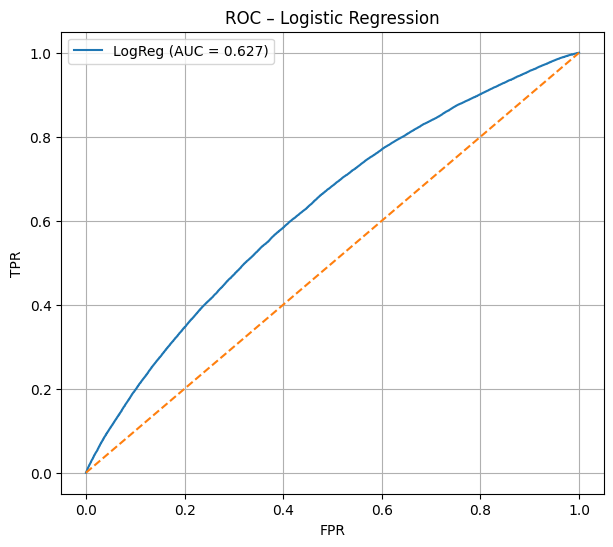

In [ ]:
fpr, tpr, _ = roc_curve(y_val, y_val_probs)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"LogReg (AUC = {auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC – Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from google.colab import drive
import os
import joblib
import scipy.sparse
import numpy as np

# 1. Montar Drive
drive.mount('/content/drive')

# 2. Definir la ruta donde guardaste los archivos
base_path = '/content/drive/My Drive/Proyecto_Vuelos_Delay/'

print("Cargando datos procesados desde Drive...")

# 3. Cargar Features (X)
X_train = scipy.sparse.load_npz(os.path.join(base_path, 'X_train.npz'))
X_val = scipy.sparse.load_npz(os.path.join(base_path, 'X_val.npz'))
X_test = scipy.sparse.load_npz(os.path.join(base_path, 'X_test.npz'))

# 4. Cargar Targets (y)
y_train = np.load(os.path.join(base_path, 'y_train.npy'), allow_pickle=True)
y_val = np.load(os.path.join(base_path, 'y_val.npy'), allow_pickle=True)
y_test = np.load(os.path.join(base_path, 'y_test.npy'), allow_pickle=True)

# 5. Cargar el Preprocesador (opcional, útil si vas a predecir datos nuevos individuales)
preprocessor = joblib.load(os.path.join(base_path, 'preprocessor.joblib'))

print(f"Datos listos.")
print(f"Dimensiones X_train: {X_train.shape}")
print(f"Dimensiones y_train: {y_train.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cargando datos procesados desde Drive...
Datos listos.
Dimensiones X_train: (6565266, 98)
Dimensiones y_train: (6565266,)


In [ ]:
X_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 27300177 stored elements and shape (2596270, 51)>

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)
import matplotlib.pyplot as plt
import numpy as np
logreg = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",      # Convexo, estable, estándar
    max_iter=1000,
    n_jobs=-1
)


In [ ]:
logreg.fit(X_train, y_train)


LogisticRegression(max_iter=1000, n_jobs=-1)

In [ ]:
y_val_probs = logreg.predict_proba(X_val)[:, 1]
y_val_pred = (y_val_probs >= 0.5).astype(int)


In [ ]:
print("Reporte de clasificación (Logistic Regression):")
print(classification_report(y_val, y_val_pred, digits=3))

auc = roc_auc_score(y_val, y_val_probs)
print("ROC–AUC:", auc)


Reporte de clasificación (Logistic Regression):
              precision    recall  f1-score   support

           0      0.846     0.778     0.810    163173
           1      0.274     0.372     0.316     36827

    accuracy                          0.703    200000
   macro avg      0.560     0.575     0.563    200000
weighted avg      0.741     0.703     0.719    200000

ROC–AUC: 0.6267744160092299


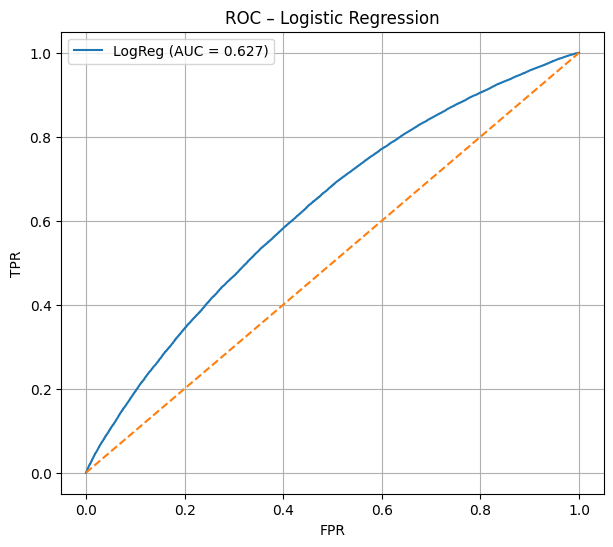

In [ ]:
fpr, tpr, _ = roc_curve(y_val, y_val_probs)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"LogReg (AUC = {auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC – Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()


(6965266, 14)
vuelo_retrasado
0    0.800598
1    0.199402
Name: proportion, dtype: float64
                        count unique    top     freq        mean         std  \
mes                 6965266.0    NaN    NaN      NaN    6.597649    3.397294   
dia_mes             6965266.0    NaN    NaN      NaN   15.790559    8.794847   
dia_semana          6965266.0    NaN    NaN      NaN    3.981578    2.012222   
fin_de_semana       6965266.0    NaN    NaN      NaN    0.276748    0.447391   
hora_salida         6965266.0    NaN    NaN      NaN   12.992417    4.897564   
minuto_salida       6965266.0    NaN    NaN      NaN    26.90934   18.208905   
distancia_millas    6965266.0    NaN    NaN      NaN  833.672759  596.338836   
tiempo_programado   6965266.0    NaN    NaN      NaN  146.705829   72.397727   
aerolinea             6965266     15     WN  1404597         NaN         NaN   
aeropuerto_origen     6965266    348    ATL   337662         NaN         NaN   
aeropuerto_destino    6965266

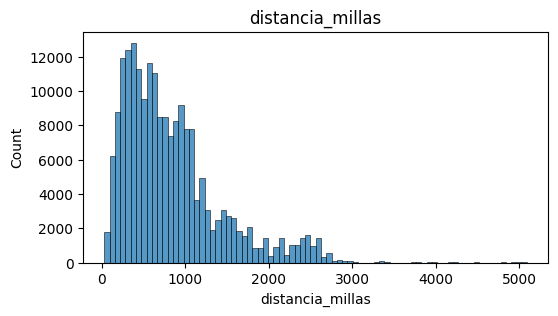

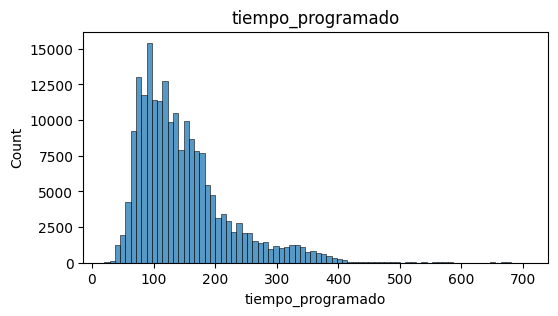

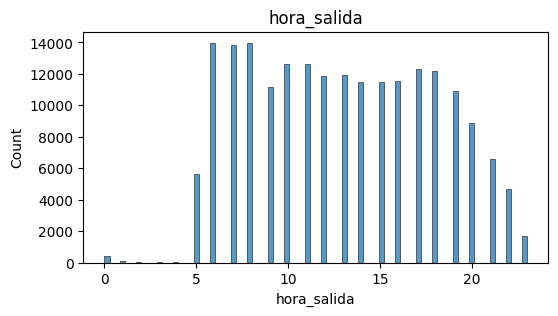

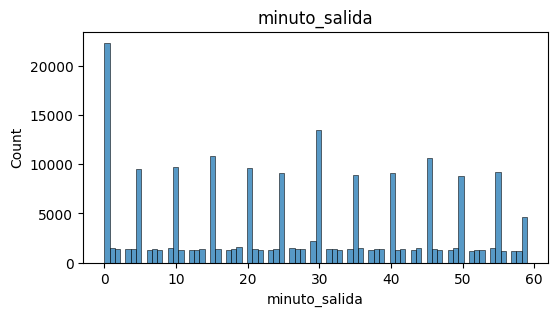

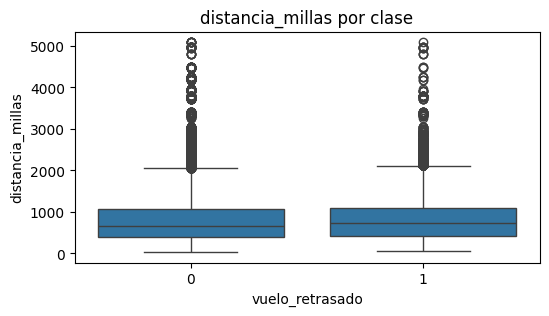

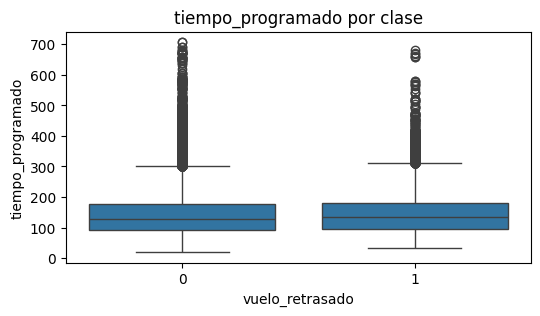

aerolinea unique: 15 top 10:
aerolinea
WN    1404597
DL     997846
AA     966116
UA     745818
OO     733886
YX     295306
MQ     275317
NK     255633
AS     240323
B6     235683
Name: count, dtype: int64

aeropuerto_origen unique: 348 top 10:
aeropuerto_origen
ATL    337662
DFW    306872
DEN    304323
ORD    275505
CLT    214096
LAX    191903
PHX    191868
LAS    186853
SEA    161520
LGA    158152
Name: count, dtype: int64

aeropuerto_destino unique: 348 top 10:
aeropuerto_destino
ATL    337703
DFW    306222
DEN    304039
ORD    275155
CLT    214036
LAX    192109
PHX    192021
LAS    187309
SEA    161399
LGA    158007
Name: count, dtype: int64

estado_origen unique: 52 top 10:
estado_origen
Texas             738049
California        732948
Florida           615504
Illinois          367677
Georgia           363687
New York          357414
Colorado          341701
North Carolina    309675
Virginia          234233
Arizona           220937
Name: count, dtype: int64

estado_destino unique:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_parquet("df_clean_modeling.parquet")

print(df.shape)
print(df['vuelo_retrasado'].value_counts(normalize=True))
print(df.describe(include='all').T)

num_cols = ['distancia_millas','tiempo_programado','hora_salida','minuto_salida']
df_sample = df.sample(n=200000, random_state=42)
for c in num_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df_sample[c], bins=80, kde=False)
    plt.title(c)
    plt.show()

for c in ['distancia_millas','tiempo_programado']:
    plt.figure(figsize=(6,3))
    sns.boxplot(x='vuelo_retrasado', y=c, data=df_sample)
    plt.title(f"{c} por clase")
    plt.show()

cat_cols = ['aerolinea','aeropuerto_origen','aeropuerto_destino','estado_origen','estado_destino']
for c in cat_cols:
    print(c, "unique:", df[c].nunique(), "top 10:")
    print(df[c].value_counts().head(10))
    print()

def top_rates(col, topn=20):
    vc = df[col].value_counts().head(topn).index
    rates = df[df[col].isin(vc)].groupby(col)['vuelo_retrasado'].mean().sort_values(ascending=False)
    return rates
print("Tasa de retraso por aerolinea (top 15):")
print(top_rates('aerolinea', 15))

df['departure_minute_of_day'] = df['hora_salida']*60 + df['minuto_salida']
agg = df.groupby(pd.cut(df['departure_minute_of_day'], bins=24)).agg({'vuelo_retrasado':['mean','count']})
print(agg.head())

print(df[['distancia_millas','tiempo_programado','departure_minute_of_day','vuelo_retrasado']].corr())


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix
import lightgbm as lgb
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

df = pd.read_parquet("df_clean_modeling.parquet")

def add_common_features(df):
    df = df.copy()
    df['departure_minute_of_day'] = df['hora_salida']*60 + df['minuto_salida']
    df['velocidad_mph'] = df['distancia_millas'] / (df['tiempo_programado'] / 60 + 1e-6)
    df['dep_sin'] = np.sin(2*np.pi*df['departure_minute_of_day']/1440)
    df['dep_cos'] = np.cos(2*np.pi*df['departure_minute_of_day']/1440)
    df['mes_sin'] = np.sin(2*np.pi*(df['mes']/12))
    df['mes_cos'] = np.cos(2*np.pi*(df['mes']/12))
    for c in ['aeropuerto_origen','aeropuerto_destino']:
        vc = df[c].value_counts(normalize=True)
        df[f'{c}_freq'] = df[c].map(vc).fillna(0.0)
    return df

df = add_common_features(df)

print("Percentiles de velocidad_mph:")
print(df['velocidad_mph'].quantile([0.999, 0.995, 0.99, 0.975, 0.95]))
cap = df['velocidad_mph'].quantile(0.999)
df['velocidad_mph_capped'] = np.where(df['velocidad_mph'] > cap, cap, df['velocidad_mph'])
print(f"Usando cap en velocidad = {cap:.2f} (99.9 percentile)")

y = df['vuelo_retrasado']
X = df.drop(columns=['vuelo_retrasado'])


X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)


num_cols = ['distancia_millas','tiempo_programado','velocidad_mph_capped','dep_sin','dep_cos','mes_sin','mes_cos','aeropuerto_origen_freq','aeropuerto_destino_freq']
ohe_cols = ['aerolinea']


encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=True)

preproc_lr = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('ohe', encoder, ohe_cols)
], sparse_threshold=0.3)


pipe_lr = Pipeline([
    ('pre', preproc_lr),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', solver='saga'))
])

print("Entrenando Logistic Regression (baseline)...")
pipe_lr.fit(X_train, y_train)
proba_lr = pipe_lr.predict_proba(X_test)[:,1]
print("LR ROC AUC:", roc_auc_score(y_test, proba_lr))
print("LR PR AUC (avg precision):", average_precision_score(y_test, proba_lr))
print("LR Confusion matrix (threshold=0.5):")
print(confusion_matrix(y_test, (proba_lr>=0.5).astype(int)))




Percentiles de velocidad_mph:
0.999    500.586422
0.995    478.113117
0.990    470.566938
0.975    456.812640
0.950    438.301057
Name: velocidad_mph, dtype: float64
Usando cap en velocidad = 500.59 (99.9 percentile)
Entrenando Logistic Regression (baseline)...
LR ROC AUC: 0.665198299120324
LR PR AUC (avg precision): 0.32246131862441185
LR Confusion matrix (threshold=0.5):
[[653069 462208]
 [ 95895 181882]]

Entrenando LightGBM (baseline)...


TypeError: train() got an unexpected keyword argument 'early_stopping_rounds'

In [ ]:

aero_map = X_train['aerolinea'].astype('category').cat.categories
train_cats = X_train['aerolinea'].astype('category')
X_train_lgb = X_train.copy()
X_train_lgb['aerolinea_code'] = train_cats.cat.codes

X_test_lgb = X_test.copy()
X_test_lgb['aerolinea_code'] = X_test_lgb['aerolinea'].map({cat:i for i,cat in enumerate(train_cats.cat.categories)}).fillna(-1).astype(int)

features_lgb = ['distancia_millas','tiempo_programado','velocidad_mph_capped','dep_sin','dep_cos','mes_sin','mes_cos','aeropuerto_origen_freq','aeropuerto_destino_freq','aerolinea_code']

lgb_train = lgb.Dataset(X_train_lgb[features_lgb], label=y_train)
lgb_val = lgb.Dataset(X_test_lgb[features_lgb], label=y_test, reference=lgb_train)

params = {'objective':'binary','metric':'auc','verbosity':-1,'boosting_type':'gbdt','is_unbalance':True}
print("\nEntrenando LightGBM (baseline)...")
bst = lgb.train(
    params=params,
    train_set=lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_train, lgb_val],
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)
proba_lgb = bst.predict(X_test_lgb[features_lgb])
print("LGB ROC AUC:", roc_auc_score(y_test, proba_lgb))
print("LGB PR AUC:", average_precision_score(y_test, proba_lgb))
print("LGB Confusion matrix (th=0.5):")
print(confusion_matrix(y_test, (proba_lgb>=0.5).astype(int)))


X_train_mlp = preproc_lr.fit_transform(X_train)
X_test_mlp  = preproc_lr.transform(X_test)


import scipy.sparse as sp
if sp.issparse(X_train_mlp):
    print("Preproc returned sparse matrix; convirtiendo a denso para MLP (usa muestra si memoria es limitada).")
    # Si hay problema de memoria, toma una submuestra para MLP
    X_train_mlp = X_train_mlp.toarray()
    X_test_mlp = X_test_mlp.toarray()

input_dim = X_train_mlp.shape[1]
model = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[tf.keras.metrics.AUC(name='auc')])
es = callbacks.EarlyStopping(monitor='val_auc', patience=5, mode='max', restore_best_weights=True)

print("\nEntrenando MLP (baseline)...")
model.fit(X_train_mlp, y_train, validation_data=(X_test_mlp, y_test), epochs=50, batch_size=2048, callbacks=[es], verbose=2)
proba_mlp = model.predict(X_test_mlp, batch_size=4096).ravel()
print("MLP ROC AUC:", roc_auc_score(y_test, proba_mlp))
print("MLP PR AUC:", average_precision_score(y_test, proba_mlp))
print("MLP Confusion matrix (th=0.5):")
print(confusion_matrix(y_test, (proba_mlp>=0.5).astype(int)))


Entrenando LightGBM (baseline)...
Training until validation scores don't improve for 50 rounds
[100]	train's auc: 0.699511	valid's auc: 0.699133
[200]	train's auc: 0.703605	valid's auc: 0.702683
[300]	train's auc: 0.706166	valid's auc: 0.704685
[400]	train's auc: 0.708085	valid's auc: 0.70602
[500]	train's auc: 0.709642	valid's auc: 0.706981
[600]	train's auc: 0.710955	valid's auc: 0.707665
[700]	train's auc: 0.712184	valid's auc: 0.708311
[800]	train's auc: 0.713324	valid's auc: 0.708909
[900]	train's auc: 0.714359	valid's auc: 0.709383
[1000]	train's auc: 0.715314	valid's auc: 0.709816
Did not meet early stopping. Best iteration is:
[1000]	train's auc: 0.715314	valid's auc: 0.709816
LGB ROC AUC: 0.7098162943914422
LGB PR AUC: 0.381731558333541
LGB Confusion matrix (th=0.5):
[[724943 390334]
 [ 95880 181897]]

Entrenando MLP (baseline)...
Epoch 1/50
2721/2721 - 45s - 17ms/step - auc: 0.6663 - loss: 0.4740 - val_auc: 0.6879 - val_loss: 0.4633
Epoch 2/50
2721/2721 - 41s - 15ms/step - a

In [ ]:

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, average_precision_score, confusion_matrix, accuracy_score, roc_curve
from sklearn.utils.class_weight import compute_class_weight
import joblib
import matplotlib.pyplot as plt

RANDOM_STATE = 42
SAVE_DIR = Path("/mnt/data")
MODEL_OUT = SAVE_DIR / "mlp_pipeline.joblib"
REPORT_OUT = SAVE_DIR / "mlp_report_summary.csv"
DECILES_OUT = SAVE_DIR / "mlp_deciles_validation.csv"


g = globals()
has_X_train = all(v in g for v in ("X_train", "y_train"))
has_full_df = "df" in g

if has_X_train:
    X_train = g["X_train"]
    y_train = np.array(g["y_train"]).ravel()
    X_val = g.get("X_val", None)
    y_val = np.array(g["y_val"]).ravel() if "y_val" in g else None
    X_test = g.get("X_test", None)
    y_test = np.array(g["y_test"]).ravel() if "y_test" in g else None
    print("Usando X_train/X_val/X_test existentes en el notebook.")
elif has_full_df:
    df = g["df"].copy()
    target_candidates = [c for c in df.columns if c.lower() in ('target','y','label','class','flight_retrasado','vuelo_retrasado','retrasado')]
    if not target_candidates:
        for c in df.columns:
            if df[c].nunique(dropna=True)==2:
                target_candidates.append(c)
    if not target_candidates:
        target = df.columns[-1]
        print("No encontré target evidente. Usando la última columna como target:", target)
    else:
        target = target_candidates[0]
        print("Target detectado:", target)
    y = df[target].astype(int).values
    X = df.drop(columns=[target])
    # split estratificado
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE)
    print("Split hecho: X_train", getattr(X_train,'shape',None), "X_val", getattr(X_val,'shape',None), "X_test", getattr(X_test,'shape',None))
else:
    raise RuntimeError("No encontré X_train ni un DataFrame 'df' en el notebook. Define tus datos o carga el df y reejecuta.")

def ensure_df(X):
    if hasattr(X, "toarray") and not isinstance(X, pd.DataFrame):  # sparse matrix
        # Mantener como sparse, ColumnTransformer manejará si es necesario
        return X
    if isinstance(X, pd.DataFrame):
        return X
    try:
        return pd.DataFrame(X)
    except Exception:
        return X

X_train = ensure_df(X_train)
X_val = ensure_df(X_val) if X_val is not None else None
X_test = ensure_df(X_test) if X_test is not None else None

# 2) Detectar columnas numéricas y categóricas si X es DataFrame
if isinstance(X_train, pd.DataFrame):
    numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()
else:
    # si X es matriz numpy/sparse, asumimos todo numérico
    numeric_cols = None
    categorical_cols = None

print("Columnas numéricas detectadas:", (len(numeric_cols) if numeric_cols is not None else "matrix/unknown"))
print("Columnas categóricas detectadas:", (len(categorical_cols) if categorical_cols is not None else 0))

# 3) Construir pipelines de preprocesamiento
# Para numeric: imputer (mean) + StandardScaler (si dense)
# Para categorical: imputer (missing) + OneHotEncoder(handle_unknown='ignore') -- advertencia: gran cardinalidad
from sklearn.pipeline import make_pipeline

if numeric_cols is not None:
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler())
    ])
else:
    numeric_transformer = None

if categorical_cols:
    # si demasiadas categorías en conjunto, podríamos usar OrdinalEncoder en lugar de OneHot para controlar dimensionalidad
    total_onehot_features = sum(X_train[c].nunique() for c in categorical_cols)
    if total_onehot_features > 500:  # heurística
        print("Advertencia: muchas categorías totales (>{}). Usaré OrdinalEncoder para evitar explosión OHE.".format(500))
        categorical_transformer = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="constant", fill_value="__MISSING__")),
            ("ordinal", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
        ])
    else:
        categorical_transformer = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="constant", fill_value="__MISSING__")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse=False))
        ])
else:
    categorical_transformer = None

if numeric_transformer and categorical_transformer:
    preprocessor = ColumnTransformer(transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ])
elif numeric_transformer:
    preprocessor = ColumnTransformer(transformers=[("num", numeric_transformer, numeric_cols)])
else:
    # matriz numérica o sparse -> solo scaler (MaxAbs si sparse)
    from scipy import sparse
    if hasattr(X_train, "toarray") or (not isinstance(X_train, pd.DataFrame) and np.issubdtype(type(X_train.flat[0]), np.number)):
        # No aplicamos ColumnTransformer; se usará StandardScaler salvo si sparse
        if hasattr(X_train, "toarray"):
            preprocessor = Pipeline([("scaler", StandardScaler(with_mean=False))])  # evitar with_mean con sparse
        else:
            preprocessor = Pipeline([("scaler", StandardScaler())])
    else:
        preprocessor = None

# 4) Calcular pesos de clase para desequilibrio
classes = np.unique(y_train)
class_weights_array = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes, class_weights_array)}
print("Pesos de clase:", class_weight)

# 5) Definir MLP dentro de un pipeline completo
mlp = MLPClassifier(hidden_layer_sizes=(256,128),
                    activation='relu',
                    solver='adam',
                    alpha=1e-4,
                    learning_rate_init=1e-3,
                    early_stopping=True,
                    validation_fraction=0.1,
                    n_iter_no_change=10,
                    max_iter=200,
                    random_state=RANDOM_STATE,
                    verbose=True)

# Construir pipeline
steps = []
if preprocessor is not None:
    steps.append(("preprocessor", preprocessor))
steps.append(("clf", mlp))
pipeline = Pipeline(steps=steps)

# 6) Entrenamiento (opción: usar RandomizedSearch para mejorar hiperparámetros)
DO_RANDOM_SEARCH = False  # cambiar a True si quieres hacer búsqueda (más tiempo)
if DO_RANDOM_SEARCH:
    param_dist = {
        "clf__hidden_layer_sizes": [(128,64), (256,128), (512,256), (256,128,64)],
        "clf__alpha": [1e-3, 1e-4, 1e-5],
        "clf__learning_rate_init": [1e-3, 5e-4, 1e-4],
    }
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    rs = RandomizedSearchCV(pipeline, param_distributions=param_dist, n_iter=12, scoring='average_precision',
                            n_jobs=-1, cv=cv, random_state=RANDOM_STATE, verbose=2)
    print("Iniciando RandomizedSearchCV (esto puede tardar bastante)...")
    rs.fit(X_train, y_train)
    pipeline = rs.best_estimator_
    print("Mejor params:", rs.best_params_)
else:
    print("Entrenando pipeline MLP (early stopping activado).")
    pipeline.fit(X_train, y_train)

# 7) Evaluación en validación y test (si existen)
def evaluate_and_report(pipeline, X, y, set_name="validation"):
    y_proba = pipeline.predict_proba(X)[:,1]
    y_pred = (y_proba >= 0.5).astype(int)
    print(f"\n--- Reporte: {set_name} ---")
    print(classification_report(y, y_pred, digits=4))
    print("Accuracy:", accuracy_score(y, y_pred))
    try:
        print("ROC AUC:", roc_auc_score(y, y_proba))
        print("Average precision (PR AUC):", average_precision_score(y, y_proba))
    except Exception as e:
        print("No se pudo calcular ROC/PR AUC:", e)
    cm = confusion_matrix(y, y_pred)
    print("Matriz de confusión:\n", cm)
    # curvas
    try:
        fpr, tpr, _ = roc_curve(y, y_proba)
        plt.figure()
        plt.plot(fpr, tpr)
        plt.title(f"ROC curve ({set_name})")
        plt.xlabel("FPR"); plt.ylabel("TPR"); plt.grid(True)
        plt.show()
    except Exception:
        pass
    return y_proba, y_pred

y_val_proba, y_val_pred = None, None
if X_val is not None and y_val is not None:
    y_val_proba, y_val_pred = evaluate_and_report(pipeline, X_val, y_val, set_name="validation")
else:
    print("No hay X_val/y_val disponibles; evaluando en X_test si existe.")

if X_test is not None and y_test is not None:
    y_test_proba, y_test_pred = evaluate_and_report(pipeline, X_test, y_test, set_name="test")
else:
    y_test_proba, y_test_pred = None, None

if y_val_proba is not None:
    val_df = pd.DataFrame({"proba": y_val_proba, "y_true": y_val})
    # Si hay probas constantes o pocos valores, qcut puede fallar; usar rank-based binning como fallback.
    try:
        val_df["decile"] = pd.qcut(val_df["proba"], 10, labels=False, duplicates='drop') + 1
    except Exception:
        val_df["decile"] = pd.qcut(val_df["proba"].rank(method="first"), 10, labels=False, duplicates='drop') + 1
    decile_table = val_df.groupby("decile").agg(
        n=("y_true","size"),
        events=("y_true","sum"),
        event_rate=("y_true","mean"),
        proba_min=("proba","min"),
        proba_max=("proba","max"),
        proba_mean=("proba","mean")
    ).reset_index().sort_values("decile", ascending=False)
    print("\nDeciles (validación):")
    display(decile_table)
    # guardar
    decile_table.to_csv(DECILES_OUT, index=False)
    print("Deciles guardados en:", DECILES_OUT)
else:
    print("No se generaron deciles: falta conjunto de validación con probabilidades.")

# 9) Guardar pipeline entrenado
os.makedirs(SAVE_DIR, exist_ok=True)
joblib.dump(pipeline, MODEL_OUT)
print("Pipeline guardado en:", MODEL_OUT)

# 10) Guardar resumen de métricas mínimas
summary_rows = []
if y_val_proba is not None:
    try:
        summary_rows.append({
            "set":"validation",
            "accuracy": accuracy_score(y_val, y_val_pred),
            "roc_auc": roc_auc_score(y_val, y_val_proba),
            "avg_precision": average_precision_score(y_val, y_val_proba)
        })
    except:
        pass
if y_test_proba is not None:
    try:
        summary_rows.append({
            "set":"test",
            "accuracy": accuracy_score(y_test, y_test_pred),
            "roc_auc": roc_auc_score(y_test, y_test_proba),
            "avg_precision": average_precision_score(y_test, y_test_proba)
        })
    except:
        pass

if summary_rows:
    pd.DataFrame(summary_rows).to_csv(REPORT_OUT, index=False)
    print("Resumen guardado en:", REPORT_OUT)
else:
    print("No se guardó resumen: no se pudieron calcular métricas numéricas completas.")

RuntimeError: No encontré X_train ni un DataFrame 'df' en el notebook. Define tus datos o carga el df y reejecuta.